In [ ]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import pearsonr

# ============================================================
# INT-3D / CLIM 2D / CLIM 3D combined 3-column figure
# Mirrors the Combined_Reanalysis_WACCM4_INT3D_NAM_AO_EPFlux_O3_2x3 logic,
# but uses outputs from Nam_calculation.ipynb and Partial_O3_with_ranking.ipynb.
# Nothing is saved; the figure is shown with plt.show().
# ============================================================

COMPONENT_CASES = {
    "BWCN": {
        "label": "BWCN",
        "nam_nc": "/mnt/soclim0/public_data/weiji/BWCN/NAM/BWCN_Vertical_NAM.nc",
        "ao_csv": "/mnt/soclim0/public_data/weiji/BWCN/NAM/BWCN_Daily_AO_Index.csv",
        "ep_nc": "/mnt/soclim0/public_data/weiji/BWCN/EPflux_daily/all_waves/EPFLUX_all_waves_24yr_time_plev_lat.nc",
        "o3_rank_csv": "/mnt/soclim0/public_data/weiji/BWCN/partial_O3/BWCN_partial_O3_ranking_MarApr_min_60_90N.csv",
        "o3_partial_nc": "/mnt/soclim0/public_data/weiji/BWCN/partial_O3/BWCN_partial_O3_all_ranges.nc",
    },
    "B2000WCN": {
        "label": "B2000WCN",
        "nam_nc": "/mnt/soclim0/public_data/weiji/B2000WCN001002_timefixed/NAM/B2000WCN001002_Vertical_NAM.nc",
        "ao_csv": "/mnt/soclim0/public_data/weiji/B2000WCN001002_timefixed/NAM/B2000WCN001002_Daily_AO_Index.csv",
        "ep_nc": "/mnt/soclim0/public_data/weiji/B2000WCN001002_timefixed/EPflux_daily/all_waves/EPFLUX_all_waves_210yr_time_plev_lat.nc",
        "o3_rank_csv": "/mnt/soclim0/public_data/weiji/B2000WCN001002_timefixed/partial_O3/B2000WCN_partial_O3_ranking_MarApr_min_60_90N.csv",
        "o3_partial_nc": "/mnt/soclim0/public_data/weiji/B2000WCN001002_timefixed/partial_O3/B2000WCN_partial_O3_all_ranges.nc",
    },
    "B2000WCN_NOCOUPL": {
        "label": "B2000WCN_NOCOUPL",
        "nam_nc": "/mnt/soclim0/public_data/weiji/B2000WCN_NOCOUPL001002_timefixed/NAM/B2000WCN_NOCOUPL001002_Vertical_NAM.nc",
        "ao_csv": "/mnt/soclim0/public_data/weiji/B2000WCN_NOCOUPL001002_timefixed/NAM/B2000WCN_NOCOUPL001002_Daily_AO_Index.csv",
        "ep_nc": "/mnt/soclim0/public_data/weiji/B2000WCN_NOCOUPL001002_timefixed/EPflux_daily/all_waves/EPFLUX_all_waves_205yr_time_plev_lat.nc",
        "o3_rank_csv": "/mnt/soclim0/public_data/weiji/B2000WCN_NOCOUPL001002_timefixed/partial_O3/B2000WCN_NOCOUPL_partial_O3_ranking_MarApr_min_60_90N.csv",
        "o3_partial_nc": "/mnt/soclim0/public_data/weiji/B2000WCN_NOCOUPL001002_timefixed/partial_O3/B2000WCN_NOCOUPL_partial_O3_all_ranges.nc",
    },
    "B2000WCN007009010011_Clim3D": {
        "label": "B2000WCN007009010011_Clim3D",
        "nam_nc": "/mnt/soclim0/public_data/weiji/B2000WCN007009010011_Clim3D_timefixed/NAM/B2000WCN007009010011_Clim3D_Vertical_NAM.nc",
        "ao_csv": "/mnt/soclim0/public_data/weiji/B2000WCN007009010011_Clim3D_timefixed/NAM/B2000WCN007009010011_Clim3D_Daily_AO_Index.csv",
        "ep_nc": "/mnt/soclim0/public_data/weiji/B2000WCN007009010011_Clim3D_timefixed/EPflux_daily/all_waves/EPFLUX_all_waves_216yr_time_plev_lat.nc",
        "o3_rank_csv": "/mnt/soclim0/public_data/weiji/B2000WCN007009010011_Clim3D_timefixed/partial_O3/B2000WCN007009010011_Clim3D_partial_O3_ranking_MarApr_min_60_90N.csv",
        "o3_partial_nc": "/mnt/soclim0/public_data/weiji/B2000WCN007009010011_Clim3D_timefixed/partial_O3/B2000WCN007009010011_Clim3D_partial_O3_all_ranges.nc",
    },
}

PLOT_ROWS = [
    {"label": "INT-3D", "case_keys": ["BWCN", "B2000WCN"]},
    {"label": "CLIM 2D", "case_keys": ["B2000WCN_NOCOUPL"]},
    {"label": "CLIM 3D", "case_keys": ["B2000WCN007009010011_Clim3D"]},
]

LAT_FZ = (40.0, 80.0)
PRESSURE_TAG = "30_70hPa"
MONTH_ENDS_NOLEAP = np.array([31, 59, 90, 120, 151, 181, 212, 243, 273, 304, 334, 365])

FIGSIZE = (17.2, 12.0)
FIG_HEIGHT_PER_ROW = FIGSIZE[1] / 2.0
PANEL_BOX_ASPECT = 1.0
TITLE_SIZE = 19
ROW_LABEL_SIZE = 17
LABEL_SIZE = 16
TICK_SIZE = 14
TEXT_SIZE = 13
LEGEND_SIZE = 14

STD_LIMIT = (-3.0, 3.0)
O3_YLIM = (70.0, 120.0)
O3_YTICKS = np.arange(70, 121, 10)
O3_VALID_MIN_DU = 10.0
O3_MARAPR_MIN_VALID_DAYS = 40
STD_TICKS = np.arange(-3, 4, 1)

BASE_COLOR = "0.25"
BASE_ALPHA = 0.42
LOW25_COLOR = "red"
TOP1_COLOR = "gold"
FIT_COLOR = "0.35"

BASE_SIZE = 58
LOW25_SIZE = 68
TOP1_SIZE = 260


def model_calendar_from_time(time_values):
    day_index = np.asarray(time_values, dtype=float).astype(np.int64)
    year = day_index // 365 + 1
    doy = day_index % 365 + 1
    month = np.searchsorted(MONTH_ENDS_NOLEAP, doy, side="left") + 1
    return year.astype(int), month.astype(int), doy.astype(int)


def add_model_calendar(da):
    year, month, doy = model_calendar_from_time(da["time"].values)
    return da.assign_coords(
        model_year=("time", year),
        model_month=("time", month),
        model_doy=("time", doy),
    )


def select_pressure_level_safe(da, coord_name, target_hpa, case_name="", var_name=""):
    vals = np.asarray(da[coord_name].values, dtype=float)
    target = target_hpa * 100.0 if np.nanmax(np.abs(vals)) > 2000 else target_hpa
    selected = float(da[coord_name].sel({coord_name: target}, method="nearest").values)
    unit_guess = "Pa" if np.nanmax(np.abs(vals)) > 2000 else "hPa"
    print(
        f"    [{case_name}] {var_name}: coord={coord_name}, "
        f"unit_guess={unit_guess}, target={target_hpa:g} hPa, selected={selected:g}"
    )
    return da.sel({coord_name: target}, method="nearest")


def sel_lat_safe(da, lat_range):
    lat0, lat1 = lat_range
    lat = da["lat"]
    if float(lat.values[0]) > float(lat.values[-1]):
        return da.sel(lat=slice(lat1, lat0))
    return da.sel(lat=slice(lat0, lat1))


def coslat_mean(da, lat_range):
    da_sub = sel_lat_safe(da, lat_range)
    weights = np.cos(np.deg2rad(da_sub["lat"]))
    return da_sub.weighted(weights).mean("lat", skipna=True)


def jfm_mean_from_model_time(da):
    da = add_model_calendar(da)
    jfm = da.where(da["model_month"].isin([1, 2, 3]), drop=True)
    return jfm.groupby("model_year").mean("time").rename({"model_year": "year"})


def djf_mean_from_model_time(da):
    da = add_model_calendar(da)
    djf_year = xr.where(da["model_month"] == 12, da["model_year"] + 1, da["model_year"])
    da = da.assign_coords(djf_year=("time", np.asarray(djf_year.values, dtype=int)))
    djf = da.where(da["model_month"].isin([12, 1, 2]), drop=True)
    return djf.groupby("djf_year").mean("time").rename({"djf_year": "year"})


def load_nam_jfm(nam_nc, case_name):
    ds = xr.open_dataset(nam_nc, decode_times=False)
    try:
        var_name = "NAM" if "NAM" in ds.data_vars else "NAM_Vertical"
        da = ds[var_name]
        lev_coord = next(c for c in ["lev", "level", "plev"] if c in da.coords or c in da.dims)
        da50 = select_pressure_level_safe(da, lev_coord, 50.0, case_name=case_name, var_name=var_name)
        return jfm_mean_from_model_time(da50)
    finally:
        ds.close()


def load_ao_jfm(ao_csv):
    df = pd.read_csv(ao_csv)
    date = df["Date"].astype(str)
    df["year"] = date.str.slice(0, 4).astype(int)
    df["month"] = date.str.slice(5, 7).astype(int)
    jfm = df[df["month"].isin([1, 2, 3])].groupby("year")["AO_Index"].mean()
    return xr.DataArray(jfm.values, coords={"year": jfm.index.values.astype(int)}, dims=["year"])


def load_ep_djf(ep_nc, case_name):
    ds = xr.open_dataset(ep_nc, decode_times=False)
    try:
        if "Fz" in ds.data_vars:
            var_name = "Fz"
        elif "EP2_cart" in ds.data_vars:
            var_name = "EP2_cart"
        elif "ep2" in ds.data_vars:
            var_name = "ep2"
        else:
            var_name = list(ds.data_vars)[0]

        da = ds[var_name]
        p_coord = next(c for c in ["plev", "lev", "level"] if c in da.coords or c in da.dims)
        da100 = select_pressure_level_safe(da, p_coord, 100.0, case_name=case_name, var_name=var_name)
        if "lat" in da100.coords:
            da100 = coslat_mean(da100, LAT_FZ)
        da100 = -1.0 * da100
        return djf_mean_from_model_time(da100)
    finally:
        ds.close()


def date_to_doy_no_leap(date_values):
    date_values = np.asarray(date_values, dtype=np.int64)
    mmdd = date_values % 10000
    month = (mmdd // 100).astype(np.int16)
    day = (mmdd % 100).astype(np.int16)
    doy = np.full(date_values.shape, -9999, dtype=np.int16)
    for m in range(1, 13):
        mask = month == m
        if np.any(mask):
            prev = int(MONTH_ENDS_NOLEAP[m - 2]) if m > 1 else 0
            doy[mask] = prev + day[mask]
    return doy


def partial_o3_calendar_from_ds(ds):
    if "date" in ds:
        dates = ds["date"].values.astype(np.int64)
        years = (dates // 10000).astype(np.int32)
        doys = date_to_doy_no_leap(dates)
        return years.astype(int), doys.astype(int)
    years, _, doys = model_calendar_from_time(ds["time"].values)
    return years.astype(int), doys.astype(int)


def load_o3_ranking_from_partial_nc(partial_o3_nc, pressure_tag=PRESSURE_TAG, rolling_days=5):
    ds = xr.open_dataset(partial_o3_nc, decode_times=False)
    try:
        if "O3_partial_60_90N" in ds:
            da = ds["O3_partial_60_90N"].sel(pressure_range=pressure_tag)
        else:
            name = f"O3_partial_60_90N_{pressure_tag}"
            if name not in ds:
                raise KeyError(f"Cannot find {name} or O3_partial_60_90N in {partial_o3_nc}")
            da = ds[name]

        years, doys = partial_o3_calendar_from_ds(ds)
        # Near-zero/non-positive partial columns are fill/break artifacts here.
        # Mask them before rolling so a bad day cannot become the annual minimum.
        da = da.where(da > O3_VALID_MIN_DU)
        if rolling_days is not None and int(rolling_days) > 1:
            da = da.rolling(time=int(rolling_days), center=True, min_periods=int(rolling_days)).mean()
        o3 = da.load().values.astype(float)
    finally:
        ds.close()

    daily = pd.DataFrame({"year": years, "doy": doys, "o3_raw": o3})
    marapr = daily[(daily["doy"] >= 60) & (daily["doy"] <= 120)].copy()
    marapr["is_valid_o3"] = np.isfinite(marapr["o3_raw"]) & (marapr["o3_raw"] > O3_VALID_MIN_DU)

    stats = (
        marapr.groupby("year", as_index=False)
        .agg(
            o3_raw=("o3_raw", lambda x: np.nanmin(x.values) if np.any(np.isfinite(x.values)) else np.nan),
            n_valid_o3_days=("is_valid_o3", "sum"),
        )
    )
    bad = stats[
        (~np.isfinite(stats["o3_raw"]))
        | (stats["o3_raw"] <= O3_VALID_MIN_DU)
        | (stats["n_valid_o3_days"] < O3_MARAPR_MIN_VALID_DAYS)
    ].copy()
    if len(bad):
        print(
            f"[WARN] Excluding {len(bad)} years from {partial_o3_nc} {pressure_tag} "
            f"rolling={rolling_days}: min O3 <= {O3_VALID_MIN_DU:g} DU or valid Mar-Apr days < {O3_MARAPR_MIN_VALID_DAYS}"
        )
        print(bad[["year", "o3_raw", "n_valid_o3_days"]].head(20).to_string(index=False))

    df = stats[
        np.isfinite(stats["o3_raw"])
        & (stats["o3_raw"] > O3_VALID_MIN_DU)
        & (stats["n_valid_o3_days"] >= O3_MARAPR_MIN_VALID_DAYS)
    ].copy()
    df["year"] = df["year"].astype(int)
    df = df.sort_values("o3_raw", ascending=True).reset_index(drop=True)
    df["rank_low_o3"] = np.arange(1, len(df) + 1, dtype=int)
    n_low25 = max(int(0.25 * len(df)), 1) if len(df) else 0
    df["is_low25"] = df["rank_low_o3"].le(n_low25)
    return df[["year", "o3_raw", "is_low25", "rank_low_o3"]].reset_index(drop=True)

def load_o3_ranking(o3_rank_csv, pressure_tag=PRESSURE_TAG, partial_o3_nc=None, rolling_days=None):
    if rolling_days is not None:
        if partial_o3_nc is None:
            raise ValueError("partial_o3_nc is required for rolling-mean O3 ranking")
        return load_o3_ranking_from_partial_nc(partial_o3_nc, pressure_tag=pressure_tag, rolling_days=rolling_days)

    df = pd.read_csv(o3_rank_csv)
    df = df[df["pressure_range"].astype(str).eq(pressure_tag)].copy()
    df["year"] = pd.to_numeric(df["year"], errors="coerce")
    df["o3_raw"] = pd.to_numeric(df["marapr_min_DU"], errors="coerce")
    df = df[
        np.isfinite(df["year"])
        & np.isfinite(df["o3_raw"])
        & (df["year"] > 0)
        & (df["o3_raw"] > O3_VALID_MIN_DU)
    ].copy()
    df["year"] = df["year"].astype(int)
    df = df.sort_values("o3_raw", ascending=True).reset_index(drop=True)
    df["rank_low_o3"] = np.arange(1, len(df) + 1, dtype=int)
    n_low25 = max(int(0.25 * len(df)), 1) if len(df) else 0
    df["is_low25"] = df["rank_low_o3"].le(n_low25)
    return df[["year", "o3_raw", "is_low25", "rank_low_o3"]].reset_index(drop=True)



def standardize_column(df, cols, prefix_note=""):
    df = df.copy()
    for col in cols:
        mu = df[col].mean()
        sd = df[col].std(ddof=0)
        if not np.isfinite(sd) or sd == 0:
            raise ValueError(f"{prefix_note} cannot standardize {col}: std={sd}")
        df[col.replace("_raw", "")] = (df[col] - mu) / sd
    return df


def standardize_ep_o3_df(df, prefix_note=""):
    df = df.copy().dropna(subset=["fz_raw", "o3_raw"])
    mu = df["fz_raw"].mean()
    sd = df["fz_raw"].std(ddof=0)
    if not np.isfinite(sd) or sd == 0:
        raise ValueError(f"{prefix_note} cannot standardize fz_raw: std={sd}")
    df["fz"] = (df["fz_raw"] - mu) / sd
    return df


def prep_component_case(case_key, info, o3_rolling_days=None):
    print(f"\nBuilding aligned component table: {info['label']}")
    da_nam = load_nam_jfm(info["nam_nc"], info["label"])
    da_ao = load_ao_jfm(info["ao_csv"])
    da_fz = load_ep_djf(info["ep_nc"], info["label"])
    df_o3_rank = load_o3_ranking(info["o3_rank_csv"], partial_o3_nc=info.get("o3_partial_nc"), rolling_days=o3_rolling_days)
    low25_set = set(df_o3_rank.loc[df_o3_rank["is_low25"], "year"].astype(int))
    o3_by_year = df_o3_rank.set_index("year")["o3_raw"]

    common_years = np.intersect1d(da_nam.year.values.astype(int), da_ao.year.values.astype(int))
    common_years = np.intersect1d(common_years, da_fz.year.values.astype(int))
    common_years = np.intersect1d(common_years, df_o3_rank["year"].values.astype(int))
    common_years = np.sort(common_years.astype(int))

    df_struct = pd.DataFrame({
        "exp": case_key,
        "year": common_years,
        "nam_raw": da_nam.sel(year=common_years).values.astype(float),
        "fz_raw": da_fz.sel(year=common_years).values.astype(float),
        "ao_raw": da_ao.sel(year=common_years).values.astype(float),
        "o3_raw": o3_by_year.loc[common_years].values.astype(float),
    })
    df_struct["is_low25"] = df_struct["year"].astype(int).isin(low25_set)
    df_struct = df_struct.dropna(subset=["nam_raw", "fz_raw", "ao_raw", "o3_raw"]).reset_index(drop=True)

    df_o3 = pd.DataFrame({
        "exp": case_key,
        "year": common_years,
        "fz_raw": da_fz.sel(year=common_years).values.astype(float),
        "o3_raw": o3_by_year.loc[common_years].values.astype(float),
    })
    df_o3["is_low25"] = df_o3["year"].astype(int).isin(low25_set)
    df_o3 = df_o3.dropna(subset=["fz_raw", "o3_raw"]).reset_index(drop=True)

    print(
        f"    common years: {common_years.min() if len(common_years) else 'NA'}-"
        f"{common_years.max() if len(common_years) else 'NA'}, n={len(common_years)}, "
        f"low25={int(df_struct['is_low25'].sum())}"
    )
    return df_struct, df_o3


def apply_row_level_low25(df_struct, df_o3, row_label):
    """Select low-O3 25% after all components in a plotted row are combined."""
    df_struct = df_struct.copy()
    df_o3 = df_o3.copy()
    n_low25 = max(int(0.25 * len(df_o3)), 1) if len(df_o3) else 0
    low_rows = df_o3.sort_values("o3_raw", ascending=True).head(n_low25)
    if "exp" in df_o3.columns:
        low_keys = set(zip(low_rows["exp"].astype(str), low_rows["year"].astype(int)))
        df_o3["is_low25"] = [
            (str(exp), int(year)) in low_keys
            for exp, year in zip(df_o3["exp"], df_o3["year"])
        ]
        df_struct["is_low25"] = [
            (str(exp), int(year)) in low_keys
            for exp, year in zip(df_struct["exp"], df_struct["year"])
        ]
    else:
        low_years = set(low_rows["year"].astype(int))
        df_o3["is_low25"] = df_o3["year"].astype(int).isin(low_years)
        df_struct["is_low25"] = df_struct["year"].astype(int).isin(low_years)
    print(
        f"    [{row_label}] row-level low25 selected after component merge: "
        f"{int(df_o3['is_low25'].sum())}/{len(df_o3)}"
    )
    return df_struct, df_o3


def prep_plot_row(row_spec, o3_rolling_days=None):
    struct_parts = []
    o3_parts = []
    for case_key in row_spec["case_keys"]:
        df_struct, df_o3 = prep_component_case(case_key, COMPONENT_CASES[case_key], o3_rolling_days=o3_rolling_days)
        struct_parts.append(df_struct)
        o3_parts.append(df_o3)

    df_struct = pd.concat(struct_parts, ignore_index=True).dropna(subset=["nam_raw", "fz_raw", "ao_raw", "o3_raw"]).reset_index(drop=True)
    df_o3 = pd.concat(o3_parts, ignore_index=True).dropna(subset=["fz_raw", "o3_raw"]).reset_index(drop=True)
    df_struct, df_o3 = apply_row_level_low25(df_struct, df_o3, row_spec["label"])

    df_struct = standardize_column(df_struct, ["nam_raw", "fz_raw", "ao_raw"], prefix_note=row_spec["label"])
    df_o3 = standardize_ep_o3_df(df_o3, prefix_note=row_spec["label"])

    print(
        f"\nAligned plot row: {row_spec['label']} "
        f"components={','.join(row_spec['case_keys'])}, "
        f"struct_n={len(df_struct)}, o3_n={len(df_o3)}, "
        f"struct_low25={int(df_struct['is_low25'].sum())}, o3_low25={int(df_o3['is_low25'].sum())}"
    )
    return df_struct, df_o3


def select_top1(df):
    if df is None or len(df) == 0:
        return None
    return df.sort_values("o3_raw", ascending=True).iloc[0]


def top1_label(row, row_name):
    if row is None:
        return f"{row_name} Top1: NA"
    if row_name == "INT-3D" and "exp" in row.index:
        return f"{row_name} Top1: {row['exp']}-{int(row['year']):04d}"
    return f"{row_name} Top1: {int(row['year']):04d}"


def find_matching_top1(df, top1_row):
    if top1_row is None:
        return None
    if "exp" in df.columns and "exp" in top1_row.index:
        m = df["exp"].eq(top1_row["exp"]) & df["year"].astype(int).eq(int(top1_row["year"]))
    else:
        m = df["year"].astype(int).eq(int(top1_row["year"]))
    if not np.any(m):
        return None
    return df.loc[m].iloc[0]


def corr_text(df, x_col, y_col, label="r"):
    clean = df[[x_col, y_col]].replace([np.inf, -np.inf], np.nan).dropna()
    if len(clean) < 3:
        return "", clean
    try:
        r, p = pearsonr(clean[x_col].values, clean[y_col].values)
        star = "*" if p < 0.05 else ""
        return f"{label} r = {r:.3f}{star}", clean
    except Exception:
        return "", clean


def plot_fit_line(ax, clean, x_col, y_col, xlim, *, color, lw, alpha, ls="-", zorder=1, clip_to_data=False):
    if len(clean) < 3 or clean[x_col].std(ddof=0) <= 0:
        return
    m, b = np.polyfit(clean[x_col].values, clean[y_col].values, 1)
    if clip_to_data:
        x0 = max(float(clean[x_col].min()), xlim[0])
        x1 = min(float(clean[x_col].max()), xlim[1])
    else:
        x0, x1 = xlim
    if x1 <= x0:
        return
    xx = np.linspace(x0, x1, 120)
    ax.plot(xx, m * xx + b, color=color, lw=lw, alpha=alpha, ls=ls, zorder=zorder)


def add_fit_and_stats(ax, df, x_col, y_col, xlim, stat_loc="upper left", low25_stat_loc=None):
    if "is_low25" in df.columns:
        low_mask = df["is_low25"].astype(bool).values
    else:
        low_mask = np.zeros(len(df), dtype=bool)

    all_txt, all_clean = corr_text(df, x_col, y_col, label="all")
    low25_df = df.loc[low_mask].copy()
    base_df = df.loc[~low_mask].copy()
    low25_txt, low25_clean = corr_text(low25_df, x_col, y_col, label="low25")
    base_txt, base_clean = corr_text(base_df, x_col, y_col, label="all-low25")

    # Three separate regressions:
    # - all: full sample, dashed black, spans the panel
    # - low25: red points only, clipped to red-point x-range
    # - all-low25: gray points only, clipped to gray-point x-range
    plot_fit_line(ax, all_clean, x_col, y_col, xlim, color="0.05", lw=1.35, alpha=0.58, ls="--", zorder=1, clip_to_data=False)
    plot_fit_line(ax, base_clean, x_col, y_col, xlim, color=BASE_COLOR, lw=1.75, alpha=0.76, ls="-", zorder=2, clip_to_data=True)
    plot_fit_line(ax, low25_clean, x_col, y_col, xlim, color=LOW25_COLOR, lw=1.85, alpha=0.90, ls="-", zorder=3, clip_to_data=True)

    if stat_loc == "upper right":
        stat_x, stat_ha = 0.96, "right"
    else:
        stat_x, stat_ha = 0.04, "left"

    stat_lines = [txt for txt in [all_txt, low25_txt, base_txt] if txt]
    if stat_lines:
        ax.text(
            stat_x, 0.96, "\n".join(stat_lines),
            transform=ax.transAxes, va="top", ha=stat_ha,
            fontsize=TEXT_SIZE, fontweight="bold",
            color="0.10",
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.76, edgecolor="none"),
            zorder=22,
        )

def scatter_points(ax, df, x_col, y_col, top1_row):
    base = ~df["is_low25"].values
    low = df["is_low25"].values

    if np.any(base):
        ax.scatter(
            df.loc[base, x_col], df.loc[base, y_col],
            s=BASE_SIZE, color=BASE_COLOR, alpha=BASE_ALPHA,
            edgecolors="none", zorder=3,
        )

    if np.any(low):
        ax.scatter(
            df.loc[low, x_col], df.loc[low, y_col],
            s=LOW25_SIZE, color=LOW25_COLOR, alpha=0.92,
            edgecolors="k", linewidths=0.55, zorder=5,
        )

    if top1_row is not None:
        ax.scatter(
            top1_row[x_col], top1_row[y_col],
            s=TOP1_SIZE, marker="*", color=TOP1_COLOR,
            edgecolors="k", linewidths=1.15, zorder=10,
        )


def style_panel(ax, xlim, ylim, xticks=None, yticks=None, xlabel="", ylabel="", show_xlabel=True):
    ax.set_box_aspect(PANEL_BOX_ASPECT)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    if xticks is not None:
        ax.set_xticks(xticks)
    if yticks is not None:
        ax.set_yticks(yticks)
    ax.grid(True, linestyle=":", color="0.65", alpha=0.65)
    ax.axhline(0, color="0.25", lw=0.9, alpha=0.45, zorder=0)
    ax.axvline(0, color="0.25", lw=0.9, alpha=0.45, zorder=0)
    if show_xlabel:
        ax.set_xlabel(xlabel, fontsize=LABEL_SIZE)
    else:
        ax.set_xlabel("")
        ax.tick_params(axis="x", labelbottom=False)
    ax.set_ylabel(ylabel, fontsize=LABEL_SIZE)
    ax.tick_params(axis="both", labelsize=TICK_SIZE)
    for spine in ax.spines.values():
        spine.set_linewidth(1.0)


def draw_panel(ax, df, top1_row, x_col, y_col, xlim, ylim,
               xlabel, ylabel, title=None, show_xlabel=True, yticks=None,
               stat_loc="upper left", low25_stat_loc=None):
    scatter_points(ax, df, x_col, y_col, top1_row)
    add_fit_and_stats(ax, df, x_col, y_col, xlim, stat_loc=stat_loc, low25_stat_loc=low25_stat_loc)
    style_panel(
        ax, xlim=xlim, ylim=ylim,
        xticks=STD_TICKS, yticks=yticks,
        xlabel=xlabel, ylabel=ylabel,
        show_xlabel=show_xlabel,
    )
    if title:
        ax.set_title(title, fontsize=TITLE_SIZE, fontweight="bold", pad=5)


def plot_combined_figure(rows, figure_title=None):
    plt.rcParams["figure.facecolor"] = "w"
    plt.rcParams["savefig.facecolor"] = "w"
    plt.rcParams["pdf.fonttype"] = 42
    plt.rcParams["ps.fonttype"] = 42
    plt.rcParams["font.size"] = TICK_SIZE

    nrows = len(rows)
    fig, axes = plt.subplots(nrows, 3, figsize=(FIGSIZE[0], FIG_HEIGHT_PER_ROW * nrows), squeeze=False)
    top_margin = 0.90 if figure_title else 0.93
    plt.subplots_adjust(left=0.105, right=0.985, top=top_margin, bottom=0.105, wspace=0.20, hspace=0.26)
    if figure_title:
        fig.suptitle(figure_title, fontsize=TITLE_SIZE, fontweight="bold", y=0.985)
    col_titles = ["AO vs NAM", "NAM vs EP flux", r"O$_3$ minimum vs EP flux"]

    top1_rows = []
    print("\nTop1 lowest-O3 years:")
    for row in rows:
        top1_o3 = select_top1(row["df_o3"])
        top1_struct = find_matching_top1(row["df_struct"], top1_o3)
        top1_rows.append((top1_struct, top1_o3))
        print("  " + top1_label(top1_o3, row["label"]))

    for r, row in enumerate(rows):
        df_struct = row["df_struct"]
        df_o3 = row["df_o3"]
        row_name = row["label"]
        top1_struct, top1_o3 = top1_rows[r]
        show_xlabel = r == nrows - 1

        draw_panel(
            axes[r, 0], df_struct, top1_struct,
            x_col="nam", y_col="ao",
            xlim=STD_LIMIT, ylim=STD_LIMIT,
            xlabel="JFM 50 hPa NAM (σ)",
            ylabel="JFM AO index (σ)",
            title=col_titles[0] if r == 0 else None,
            show_xlabel=show_xlabel,
            yticks=STD_TICKS,
        )

        draw_panel(
            axes[r, 1], df_struct, top1_struct,
            x_col="fz", y_col="nam",
            xlim=STD_LIMIT, ylim=STD_LIMIT,
            xlabel=r"DJF 100 hPa EP-flux metric (σ)",
            ylabel="JFM 50 hPa NAM (σ)",
            title=col_titles[1] if r == 0 else None,
            show_xlabel=show_xlabel,
            yticks=STD_TICKS,
            stat_loc="upper right",
        )

        draw_panel(
            axes[r, 2], df_o3, top1_o3,
            x_col="fz", y_col="o3_raw",
            xlim=STD_LIMIT, ylim=O3_YLIM,
            xlabel=r"DJF 100 hPa EP-flux metric (σ)",
            ylabel=r"Mar-Apr minimum O$_3$ (DU)",
            title=col_titles[2] if r == 0 else None,
            show_xlabel=show_xlabel,
            yticks=O3_YTICKS,
            low25_stat_loc="lower right" if r == nrows - 1 else None,
        )

        axes[r, 0].text(
            -0.43, 0.50, row_name,
            transform=axes[r, 0].transAxes,
            rotation=90, va="center", ha="center",
            fontsize=ROW_LABEL_SIZE, fontweight="bold",
        )

    legend_handles = [
        Line2D([0], [0], marker="o", color="none", label="Low-O3 25% years",
               markerfacecolor=LOW25_COLOR, markeredgecolor="k", markeredgewidth=0.55,
               markersize=9.0),
        Line2D([0], [0], color="0.05", linestyle="--", lw=1.35, label="all fit"),
        Line2D([0], [0], color=LOW25_COLOR, linestyle="-", lw=1.85, label="low25 fit"),
        Line2D([0], [0], color=BASE_COLOR, linestyle="-", lw=1.75, label="all-low25 fit"),
    ]
    for row, (_, top1_o3) in zip(rows, top1_rows):
        legend_handles.append(
            Line2D([0], [0], marker="*", color="none", label=top1_label(top1_o3, row["label"]),
                   markerfacecolor=TOP1_COLOR, markeredgecolor="k", markeredgewidth=1.15,
                   markersize=15.0)
        )
    legend_handles.append(
        Line2D([0], [0], linestyle="none", marker="", color="none",
               label="* statistically significant (p < 0.05)")
    )

    fig.legend(
        handles=legend_handles,
        loc="lower center", bbox_to_anchor=(0.52, 0.025),
        ncol=min(len(legend_handles), 5), fontsize=LEGEND_SIZE,
        frameon=True, facecolor="white", edgecolor="0.80",
    )
    plt.show()



def pearson_manual(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    ok = np.isfinite(x) & np.isfinite(y)
    x = x[ok]
    y = y[ok]
    if len(x) < 3:
        return np.nan
    x_anom = x - x.mean()
    y_anom = y - y.mean()
    denom = np.sqrt(np.sum(x_anom ** 2) * np.sum(y_anom ** 2))
    if denom == 0 or not np.isfinite(denom):
        return np.nan
    return float(np.sum(x_anom * y_anom) / denom)


def regression_slope(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    ok = np.isfinite(x) & np.isfinite(y)
    x = x[ok]
    y = y[ok]
    if len(x) < 3 or np.std(x, ddof=0) == 0:
        return np.nan
    return float(np.polyfit(x, y, 1)[0])


def corr_stats_for_subset(df, mask, subset_label):
    sub = df.loc[mask, ["exp", "year", "fz", "o3_raw"]].replace([np.inf, -np.inf], np.nan).dropna()
    if len(sub) < 3:
        return {
            "subset": subset_label,
            "n": len(sub),
            "scipy_r": np.nan,
            "manual_r": np.nan,
            "p_value": np.nan,
            "slope_DU_per_sigma": np.nan,
            "fz_std": np.nan,
            "o3_std": np.nan,
            "fz_minmax": "NA",
            "o3_minmax": "NA",
        }
    r, p = pearsonr(sub["fz"].values, sub["o3_raw"].values)
    return {
        "subset": subset_label,
        "n": len(sub),
        "scipy_r": round(float(r), 6),
        "manual_r": round(pearson_manual(sub["fz"].values, sub["o3_raw"].values), 6),
        "p_value": round(float(p), 6),
        "slope_DU_per_sigma": round(regression_slope(sub["fz"].values, sub["o3_raw"].values), 6),
        "fz_std": round(float(sub["fz"].std(ddof=0)), 6),
        "o3_std": round(float(sub["o3_raw"].std(ddof=0)), 6),
        "fz_minmax": f"{sub['fz'].min():.2f}..{sub['fz'].max():.2f}",
        "o3_minmax": f"{sub['o3_raw'].min():.2f}..{sub['o3_raw'].max():.2f}",
    }


def print_o3_ep_corr_sanity(rows, label):
    print(f"\nCorrelation sanity check for O3 minimum vs EP flux: {label}")
    out_rows = []
    for row in rows:
        df = row["df_o3"].copy()
        low = df["is_low25"].astype(bool).values
        for subset_label, mask in [
            ("all", np.ones(len(df), dtype=bool)),
            ("low25", low),
            ("all-low25", ~low),
        ]:
            rec = corr_stats_for_subset(df, mask, subset_label)
            rec = {"row": row["label"], **rec}
            out_rows.append(rec)
    out = pd.DataFrame(out_rows)
    print(out.to_string(index=False))
    print("Check: scipy_r and manual_r should match; low25 is selected after all row components are merged.")
    return out

rows = []
for row_spec in PLOT_ROWS:
    df_struct, df_o3 = prep_plot_row(row_spec, o3_rolling_days=None)
    rows.append({"label": row_spec["label"], "df_struct": df_struct, "df_o3": df_o3})

plot_combined_figure(rows)
block1_corr_sanity_raw = print_o3_ep_corr_sanity(rows, "raw MA minimum O3")


# Extra copy of the 9-panel figure: low-O3 years are re-selected from
# March-April minima after a centered 5-day running mean of partial O3.
rows_5day_o3 = []
for row_spec in PLOT_ROWS:
    df_struct, df_o3 = prep_plot_row(row_spec, o3_rolling_days=5)
    rows_5day_o3.append({"label": row_spec["label"], "df_struct": df_struct, "df_o3": df_o3})

plot_combined_figure(
    rows_5day_o3,
    figure_title="MA minimum O3 after 5-day running mean",
)
block1_corr_sanity_5day = print_o3_ep_corr_sanity(rows_5day_o3, "5-day running-mean MA minimum O3")


## WACCM-style FWD response: raw vs 5-day O3-year selection

This block draws two 2x2 comparison figures. Each figure has INT-3D vs CLIM-3D and INT-3D vs CLIM-2D rows, with MA and M-FWD columns. The first figure uses unsmoothed O3 extrema for the low/high ozone-year selection; the second uses a 5-day running mean.


Friedel et al. (2022) Table 1 reference:
   Experiment Mean FSW date Mean FSW date low-ozone springs Mean FSW date high-ozone springs
 WACCM INT-3D      26 April            10 May (1 hPa-first)          17 April (10 hPa-first)
WACCM CLIM-3D      22 April              27 April (neutral)          21 April (10 hPa-first)
 SOCOL INT-3D      17 April          27 April (1 hPa-first)           1 April (10 hPa-first)
SOCOL CLIM-3D      16 April              17 April (neutral)          10 April (10 hPa-first)
       MERRA2       5 April         11 April (10 hPa-first)          25 March (10 hPa-first)

Table-1-like check at nearest 50 hPa: raw O3 extrema, no 5-day running mean
O3 window Experiment  nearest level hPa                ranking source all mean date low mean date  low anomaly d high mean date  high anomaly d n low/high
       MA     INT-3D               50.0 our partial_O3 raw O3 extrema        23 Apr        03 May           9.39         17 Apr           -6.77      52/52
       MA    C

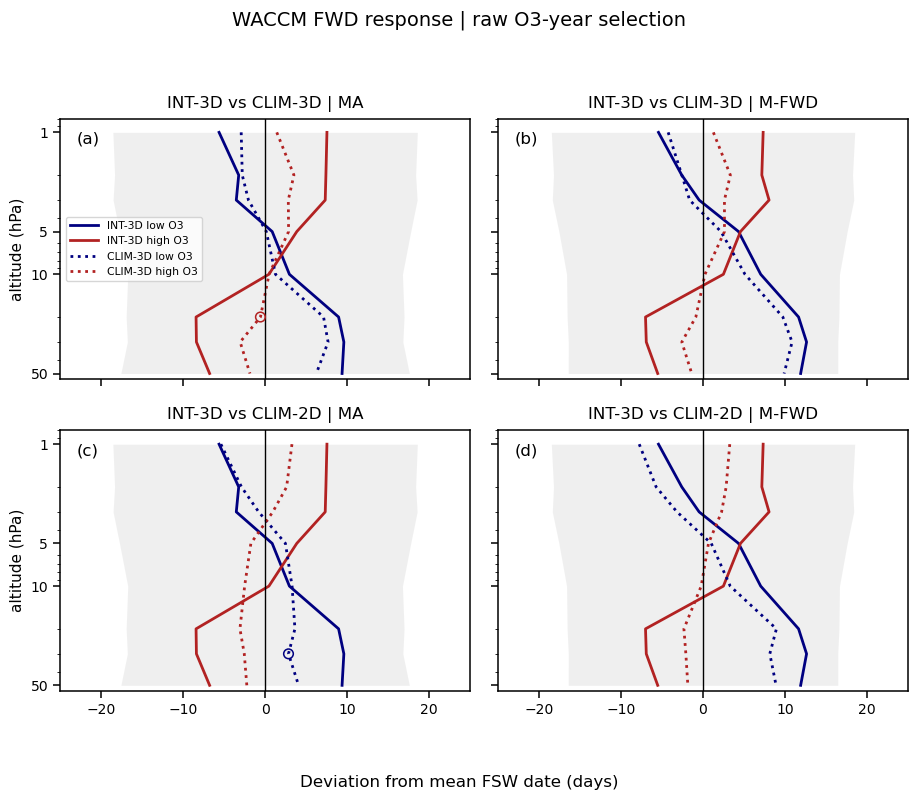


Table-1-like check at nearest 50 hPa: 5-day running-mean O3 extrema
O3 window Experiment  nearest level hPa                               ranking source all mean date low mean date  low anomaly d high mean date  high anomaly d n low/high
       MA     INT-3D               50.0 our partial_O3 5-day running-mean O3 extrema        23 Apr        04 May          11.03         17 Apr           -6.21      52/52
       MA    CLIM-3D               50.0                           Marina runmean5 O3        22 Apr        27 Apr           5.45         21 Apr           -1.23      50/50
       MA    CLIM-2D               50.0 our partial_O3 5-day running-mean O3 extrema        21 Apr        25 Apr           3.83         19 Apr           -1.88      51/51
    M-FWD     INT-3D               50.0 our partial_O3 5-day running-mean O3 extrema        24 Apr        06 May          11.91         19 Apr           -5.43      51/51
    M-FWD    CLIM-3D               50.0                           Marina runmean5

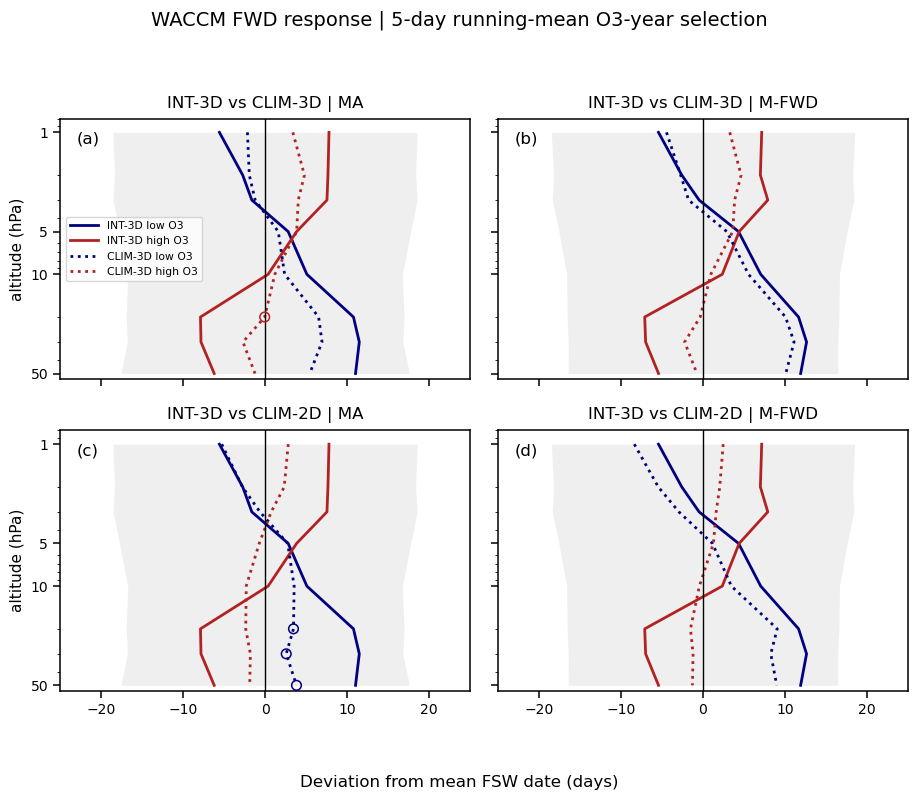

In [2]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind


FWD_INT3D_FWD_NC = "/mnt/soclim0/public_data/weiji/B2000WCN001002_timefixed/final_warming_date/B2000WCN001002_FWD_plev_year.nc"
FWD_INT3D_PARTIAL_O3_NC = "/mnt/soclim0/public_data/weiji/B2000WCN001002_timefixed/partial_O3/B2000WCN_partial_O3_all_ranges.nc"
FWD_CLIM2D_FWD_NC = "/mnt/soclim0/public_data/weiji/B2000WCN_NOCOUPL001002_timefixed/final_warming_date/B2000WCN_NOCOUPL001002_FWD_plev_year.nc"
FWD_CLIM2D_PARTIAL_O3_NC = "/mnt/soclim0/public_data/weiji/B2000WCN_NOCOUPL001002_timefixed/partial_O3/B2000WCN_NOCOUPL_partial_O3_all_ranges.nc"
FWD_CLIM3D_OUR_FWD_NC = "/mnt/soclim0/public_data/weiji/B2000WCN007009010011_Clim3D_timefixed/final_warming_date/B2000WCN007009010011_Clim3D_FWD_plev_year.nc"
FWD_CLIM3D_OUR_PARTIAL_O3_NC = "/mnt/soclim0/public_data/weiji/B2000WCN007009010011_Clim3D_timefixed/partial_O3/B2000WCN007009010011_Clim3D_partial_O3_all_ranges.nc"

FWD_CLIM3D_MARINA_U_NC = "/mnt/backup_ETH/Marina/WACCM/NOCHEM_2000_3D/combined/B2000WCN.NOCOUPL.e122.f19_g16.int.zm.nc"
FWD_CLIM3D_MARINA_RAW_O3_NC = "/mnt/backup_ETH/Marina/WACCM/NOCHEM_2000_3D/combined/B2000WCN.NOCOUPL.e122.f19_g16.int.zm.nc"
FWD_CLIM3D_MARINA_RUNMEAN5_O3_NC = "/mnt/backup_ETH/Marina/WACCM/NOCHEM_2000_3D/combined/B2000WCN.NOCOUPL.e122.f19_g16.int.zm.runmean5.nc"
FWD_CLIM3D_MARINA_SAVED_NPY = "/home/gchiodo/code/Marina/python-scripts-main/Friedel et al., 2022: \"Effects of Arctic ozone on the stratospheric spring onset and its surface impact\"/FW_dates/FW_vertical_newthreshIII_1.npy"
FWD_INT3D_MARINA_U_NC = "/mnt/backup_ETH/Marina/ozone_extremes/WACCM/INT_O3_2000/U.101-300.zm.nc"

FWD_O3_PRESSURE_RANGE = "30_70hPa"
FWD_ONSET_LEVEL_HPA = 50.0
FWD_O3_MIN_VALID_DAYS = 5
FWD_O3_VALID_MIN_DU = 10.0
FWD_TTEST_EQUAL_VAR = False
FWD_LOW_COLOR = "navy"
FWD_HIGH_COLOR = "firebrick"
FWD_COMMON_LEVELS_HPA = np.array([1, 2, 3, 5, 10, 20, 30, 50], dtype=float)

FWD_CLIM3D_CHUNKS = [
    {"our_start": 11, "our_end": 62, "marina_start": 7, "marina_end": 58},
    {"our_start": 63, "our_end": 110, "marina_start": 102, "marina_end": 149},
    {"our_start": 111, "our_end": 162, "marina_start": 50, "marina_end": 101},
    {"our_start": 163, "our_end": 210, "marina_start": 153, "marina_end": 200},
]

FWD_CASES = {
    "INT-3D": {
        "fwd_nc": FWD_INT3D_FWD_NC,
        "partial_o3_nc": FWD_INT3D_PARTIAL_O3_NC,
        "linestyle": "-",
        "shade": True,
        "ranking_family": "our partial_O3",
    },
    "CLIM-3D": {
        "fwd_nc": FWD_CLIM3D_OUR_FWD_NC,
        "partial_o3_nc": FWD_CLIM3D_OUR_PARTIAL_O3_NC,
        "marina_saved_fwd_npy": FWD_CLIM3D_MARINA_SAVED_NPY,
        "marina_u_nc": FWD_CLIM3D_MARINA_U_NC,
        "marina_raw_o3_nc": FWD_CLIM3D_MARINA_RAW_O3_NC,
        "marina_runmean5_o3_nc": FWD_CLIM3D_MARINA_RUNMEAN5_O3_NC,
        "linestyle": ":",
        "shade": False,
        "ranking_family": "Marina CLIM-3D O3",
    },
    "CLIM-2D": {
        "fwd_nc": FWD_CLIM2D_FWD_NC,
        "partial_o3_nc": FWD_CLIM2D_PARTIAL_O3_NC,
        "linestyle": ":",
        "shade": False,
        "ranking_family": "our partial_O3",
    },
}

FWD_O3_WINDOW_SPECS = {
    "MA": {"title": "MA", "start_doy": 60, "end_doy": 120, "needs_fwd": False},
    "M-FWD": {"title": "M-FWD", "start_doy": 60, "end_doy": None, "needs_fwd": True},
}
FWD_O3_WINDOW_ORDER = ["MA", "M-FWD"]
FWD_COMPARE_ROWS = ["CLIM-3D", "CLIM-2D"]

FWD_MONTH_ENDS_NOLEAP = np.array([31, 59, 90, 120, 151, 181, 212, 243, 273, 304, 334, 365], dtype=np.int16)
FWD_MONTH_NAMES = np.array(["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])


def fwd_date_to_doy(date_values):
    date_values = np.asarray(date_values, dtype=np.int64)
    mmdd = date_values % 10000
    month = (mmdd // 100).astype(np.int16)
    day = (mmdd % 100).astype(np.int16)
    doy = np.full(date_values.shape, -9999, dtype=np.int16)
    for m in range(1, 13):
        mask = month == m
        if np.any(mask):
            prev = int(FWD_MONTH_ENDS_NOLEAP[m - 2]) if m > 1 else 0
            doy[mask] = prev + day[mask]
    return doy


def doy_to_month_day(doy):
    if not np.isfinite(doy):
        return "nan"
    d = int(np.round(float(doy)))
    d = min(max(d, 1), 365)
    month_idx = int(np.searchsorted(FWD_MONTH_ENDS_NOLEAP, d, side="left"))
    prev = int(FWD_MONTH_ENDS_NOLEAP[month_idx - 1]) if month_idx > 0 else 0
    return f"{d - prev:02d} {FWD_MONTH_NAMES[month_idx]}"


def fwd_calendar_from_ds(ds):
    if "date" in ds:
        dates = ds["date"].values.astype(np.int64)
        years = (dates // 10000).astype(np.int32)
        doys = fwd_date_to_doy(dates)
        return years.astype(int), doys.astype(int)
    day_index = np.asarray(ds["time"].values, dtype=float).astype(np.int64)
    years = (day_index // 365 + 1).astype(np.int32)
    doys = (day_index % 365 + 1).astype(np.int16)
    return years.astype(int), doys.astype(int)


def rolling_label(rolling_days):
    return "raw O3 extrema" if rolling_days is None else f"{int(rolling_days)}-day running-mean O3 extrema"


def fwd_marina_saved_levels_hpa(u_nc):
    ds = xr.open_dataset(u_nc, decode_times=False)
    try:
        p = ds["plev"].values.astype(float)
    finally:
        ds.close()
    return p[(p >= 10.0) & (p <= 5000.0)] / 100.0 if np.nanmax(p) > 1000 else p[(p >= 1.0) & (p <= 50.0)]


def fwd_select_common_levels(fwd):
    fwd = fwd.where((fwd["plev_hpa"] >= 1.0) & (fwd["plev_hpa"] <= 50.0), drop=True)
    p_hpa = fwd["plev_hpa"].values.astype(float)
    keep = []
    seen = set()
    for target in FWD_COMMON_LEVELS_HPA:
        idx = int(np.nanargmin(np.abs(p_hpa - target)))
        key = round(float(p_hpa[idx]), 6)
        if key not in seen:
            keep.append(idx)
            seen.add(key)
    return fwd.isel(plev=keep)


def load_fwd_for_case(cfg):
    if cfg.get("marina_saved_fwd_npy"):
        p_hpa = fwd_marina_saved_levels_hpa(cfg["marina_u_nc"])
        arr = np.load(cfg["marina_saved_fwd_npy"]).astype(float).T
        years = np.arange(1, arr.shape[0] + 1, dtype=int)
        fwd = xr.DataArray(
            arr,
            dims=("year", "plev"),
            coords={"year": years, "plev": np.arange(len(p_hpa)), "plev_hpa": ("plev", p_hpa)},
            name="FWD_dayofyear",
        )
        return fwd_select_common_levels(fwd)

    ds = xr.open_dataset(cfg["fwd_nc"])
    try:
        fwd = ds["FWD_dayofyear"].load()
        p_hpa = ds["plev_hpa"].values.astype(float) if "plev_hpa" in ds else ds["plev"].values.astype(float) / 100.0
        fwd = fwd.assign_coords(plev_hpa=("plev", p_hpa))
        return fwd_select_common_levels(fwd)
    finally:
        ds.close()


def load_partial_o3_series(partial_o3_nc, rolling_days=None, pressure_range=FWD_O3_PRESSURE_RANGE):
    ds = xr.open_dataset(partial_o3_nc, decode_times=False)
    try:
        if "O3_partial_60_90N" in ds:
            da = ds["O3_partial_60_90N"].sel(pressure_range=pressure_range)
        else:
            name = f"O3_partial_60_90N_{pressure_range}"
            if name not in ds:
                raise KeyError(f"Cannot find {name} or O3_partial_60_90N in {partial_o3_nc}")
            da = ds[name]
        years, doys = fwd_calendar_from_ds(ds)
        da = da.where(da > FWD_O3_VALID_MIN_DU)
        if rolling_days is not None and int(rolling_days) > 1:
            da = da.rolling(time=int(rolling_days), center=True, min_periods=int(rolling_days)).mean()
        vals = da.load().values.astype(float)
        return vals, years, doys
    finally:
        ds.close()


def load_marina_o3_series(o3_nc, rolling_days=None):
    ds = xr.open_dataset(o3_nc, decode_times=False)
    try:
        o3 = ds["O3"].interp(lat=np.linspace(-90.0, 90.0, 73))
        plev = ds["plev"]
        p_values = plev.values.astype(float)
        delta_p = np.zeros(len(p_values), dtype=float)
        for level in range(1, len(p_values)):
            delta_p[level] = p_values[level] - p_values[level - 1]

        o3 = o3.sel(lat=slice(60, 90))
        weights_lat = np.cos(np.deg2rad(o3["lat"]))
        o3 = o3.weighted(weights_lat).mean(dim="lat")

        weights_p = xr.DataArray(delta_p, dims=["plev"], coords={"plev": plev})
        m_air = 28.964 / (6.022e23)
        g = 980.6
        o3_du = o3 * weights_p * 10.0 / (g * m_air)
        o3_du = o3_du.sel(plev=slice(3000, 7000)).sum(dim="plev") / 2.687e16
        if "lon" in o3_du.dims:
            o3_du = o3_du.mean("lon", skipna=True)
        if rolling_days is not None and int(rolling_days) > 1:
            o3_du = o3_du.rolling(time=int(rolling_days), center=True, min_periods=int(rolling_days)).mean()

        vals = o3_du.load().values.astype(float)
        ntime = vals.shape[0]
        day_index = np.arange(ntime, dtype=np.int64)
        years = (day_index // 365 + 1).astype(int)
        doys = (day_index % 365 + 1).astype(int)
        return vals, years, doys
    finally:
        ds.close()


def onset_series_for_years(fwd, years, onset_level_hpa=FWD_ONSET_LEVEL_HPA):
    p_hpa = fwd["plev_hpa"].values.astype(float)
    idx = int(np.nanargmin(np.abs(p_hpa - onset_level_hpa)))
    selected = fwd.isel(plev=idx).sel(year=list(years))
    return pd.Series(selected.values.astype(float), index=np.asarray(years, dtype=int)).dropna()


def load_low_high_from_series(o3_values, years_by_time, doys_by_time, window_mode, candidate_years, onset_by_year=None):
    spec = FWD_O3_WINDOW_SPECS[window_mode]
    available_years = set(np.asarray(years_by_time, dtype=int).tolist())
    candidate_years = sorted(int(y) for y in candidate_years if int(y) in available_years)
    records = []
    for year in candidate_years:
        start_doy = int(spec["start_doy"])
        if spec["needs_fwd"]:
            if onset_by_year is None or year not in onset_by_year.index:
                continue
            onset_doy = float(onset_by_year.loc[year])
            if not np.isfinite(onset_doy) or onset_doy < start_doy:
                continue
            end_doy = int(round(onset_doy))
        else:
            onset_doy = np.nan
            end_doy = int(spec["end_doy"])
        mask = (years_by_time == int(year)) & (doys_by_time >= start_doy) & (doys_by_time <= end_doy)
        vals = np.asarray(o3_values[mask], dtype=float)
        vals = vals[np.isfinite(vals) & (vals > FWD_O3_VALID_MIN_DU)]
        if vals.size < FWD_O3_MIN_VALID_DAYS:
            continue
        records.append({
            "year": int(year),
            "window_min_DU": float(np.min(vals)),
            "window_max_DU": float(np.max(vals)),
            "window_mean_DU": float(np.mean(vals)),
            "n_valid_o3_days": int(vals.size),
            "window_start_doy": start_doy,
            "window_end_doy": end_doy,
            "fsw_onset_doy": onset_doy,
        })
    df = pd.DataFrame(records)
    if df.empty:
        raise ValueError(f"No valid O3 windows for {window_mode}")
    n25 = max(int(np.floor(0.25 * len(df))), 1)
    low_years = sorted(df.nsmallest(n25, "window_min_DU")["year"].astype(int).tolist())
    high_years = sorted(df.nlargest(n25, "window_max_DU")["year"].astype(int).tolist())
    df["is_low_o3_spring"] = df["year"].isin(low_years)
    df["is_high_o3_spring"] = df["year"].isin(high_years)
    return low_years, high_years, df.sort_values("year").reset_index(drop=True)


def o3_series_for_case(label, cfg, rolling_days, cache):
    key = (label, rolling_days)
    if key in cache:
        return cache[key]
    if cfg.get("marina_raw_o3_nc"):
        if rolling_days is None:
            out = (*load_marina_o3_series(cfg["marina_raw_o3_nc"], rolling_days=None), "Marina raw O3")
        else:
            out = (*load_marina_o3_series(cfg["marina_runmean5_o3_nc"], rolling_days=None), "Marina runmean5 O3")
    else:
        out = (*load_partial_o3_series(cfg["partial_o3_nc"], rolling_days=rolling_days), cfg["ranking_family"] + " " + rolling_label(rolling_days))
    cache[key] = out
    return out


def load_profile(label, cfg, window_mode, rolling_days, o3_cache):
    fwd = load_fwd_for_case(cfg)
    p_hpa = fwd["plev_hpa"].values.astype(float)
    available_fwd_years = sorted(fwd["year"].values.astype(int).tolist())
    onset_by_year = onset_series_for_years(fwd, available_fwd_years)
    o3_values, years_by_time, doys_by_time, ranking_source = o3_series_for_case(label, cfg, rolling_days, o3_cache)
    low_years, high_years, rank_df = load_low_high_from_series(
        o3_values,
        years_by_time,
        doys_by_time,
        window_mode=window_mode,
        candidate_years=available_fwd_years,
        onset_by_year=onset_by_year,
    )
    all_years = rank_df["year"].astype(int).tolist()
    fwd_all = fwd.sel(year=all_years).transpose("year", "plev")
    low = fwd.sel(year=low_years).transpose("year", "plev")
    high = fwd.sel(year=high_years).transpose("year", "plev")
    all_mean = fwd_all.mean("year", skipna=True)
    all_std = fwd_all.std("year", skipna=True)
    low_dev = (low - all_mean).transpose("year", "plev")
    high_dev = (high - all_mean).transpose("year", "plev")
    return {
        "label": label,
        "window_mode": window_mode,
        "rolling_days": rolling_days,
        "ranking_source": ranking_source,
        "p_hpa": p_hpa,
        "all_mean": all_mean.values.astype(float),
        "all_std": all_std.values.astype(float),
        "low_mean_abs": low.mean("year", skipna=True).values.astype(float),
        "high_mean_abs": high.mean("year", skipna=True).values.astype(float),
        "low_mean_dev": low_dev.mean("year", skipna=True).values.astype(float),
        "high_mean_dev": high_dev.mean("year", skipna=True).values.astype(float),
        "low_values": low.values.astype(float),
        "high_values": high.values.astype(float),
        "low_dev_values": low_dev.values.astype(float),
        "high_dev_values": high_dev.values.astype(float),
        "rank_df": rank_df,
        "all_years": all_years,
        "low_years": low_years,
        "high_years": high_years,
        "linestyle": cfg["linestyle"],
        "shade": cfg["shade"],
    }


def load_profiles_by_window(rolling_days=None):
    o3_cache = {}
    profiles = {}
    for window_mode in FWD_O3_WINDOW_ORDER:
        profiles[window_mode] = {}
        for label, cfg in FWD_CASES.items():
            profiles[window_mode][label] = load_profile(label, cfg, window_mode, rolling_days, o3_cache)
    return profiles


def ttest_mask(values_a, values_b, alpha=0.05):
    values_a = np.asarray(values_a, dtype=float)
    values_b = np.asarray(values_b, dtype=float)
    nlev = values_a.shape[1]
    mask = np.zeros(nlev, dtype=bool)
    pvals = np.full(nlev, np.nan, dtype=float)
    for i in range(nlev):
        a = values_a[:, i]
        b = values_b[:, i]
        a = a[np.isfinite(a)]
        b = b[np.isfinite(b)]
        if len(a) < 2 or len(b) < 2:
            continue
        _, p = ttest_ind(a, b, equal_var=FWD_TTEST_EQUAL_VAR, nan_policy="omit")
        pvals[i] = p
        mask[i] = np.isfinite(p) and p < alpha
    return mask, pvals


def response_xmax(profiles_by_window):
    vals = []
    for window_profiles in profiles_by_window.values():
        for prof in window_profiles.values():
            vals.extend(prof["low_mean_dev"][np.isfinite(prof["low_mean_dev"])])
            vals.extend(prof["high_mean_dev"][np.isfinite(prof["high_mean_dev"])])
    xmax = max(10.0, np.ceil((np.nanmax(np.abs(vals)) + 3.0) / 5.0) * 5.0)
    return min(max(xmax, 25.0), 40.0)


def draw_response_panel(ax, profiles, compare_label, panel_label, title, xmax, show_ylabel=False, show_legend=False):
    int3d = profiles["INT-3D"]
    comp = profiles[compare_label]
    p_hpa = int3d["p_hpa"]
    if int3d["shade"]:
        ax.fill_betweenx(p_hpa, -int3d["all_std"], int3d["all_std"], color="0.85", alpha=0.40, lw=0)
    ax.plot(int3d["low_mean_dev"], p_hpa, color=FWD_LOW_COLOR, lw=2.0, ls=int3d["linestyle"], label="INT-3D low O3")
    ax.plot(int3d["high_mean_dev"], p_hpa, color=FWD_HIGH_COLOR, lw=2.0, ls=int3d["linestyle"], label="INT-3D high O3")
    ax.plot(comp["low_mean_dev"], comp["p_hpa"], color=FWD_LOW_COLOR, lw=2.0, ls=comp["linestyle"], label=f"{compare_label} low O3")
    ax.plot(comp["high_mean_dev"], comp["p_hpa"], color=FWD_HIGH_COLOR, lw=2.0, ls=comp["linestyle"], label=f"{compare_label} high O3")

    low_sig, _ = ttest_mask(int3d["low_dev_values"], comp["low_dev_values"])
    high_sig, _ = ttest_mask(int3d["high_dev_values"], comp["high_dev_values"])
    ax.scatter(comp["low_mean_dev"][low_sig], comp["p_hpa"][low_sig], s=48, facecolors="none", edgecolors=FWD_LOW_COLOR, lw=1.1, zorder=6)
    ax.scatter(comp["high_mean_dev"][high_sig], comp["p_hpa"][high_sig], s=48, facecolors="none", edgecolors=FWD_HIGH_COLOR, lw=1.1, zorder=6)
    print(f"{profiles['INT-3D']['window_mode']} | significant low-O3 levels INT-3D vs {compare_label}:", comp["p_hpa"][low_sig].tolist())
    print(f"{profiles['INT-3D']['window_mode']} | significant high-O3 levels INT-3D vs {compare_label}:", comp["p_hpa"][high_sig].tolist())

    ax.axvline(0, color="k", lw=1.0)
    ax.set_xlim(-xmax, xmax)
    ax.set_xscale("linear")
    ax.set_yscale("log")
    ax.set_ylim(55.0, 0.8)
    ax.set_yticks([1, 5, 10, 50])
    ax.set_yticklabels(["1", "5", "10", "50"])
    ax.set_title(title, fontsize=12, pad=8)
    ax.text(0.04, 0.95, panel_label, transform=ax.transAxes, fontsize=12, va="top")
    ax.tick_params(axis="both", labelsize=10, width=1.1, length=5)
    if show_ylabel:
        ax.set_ylabel("altitude (hPa)", fontsize=11)
    for spine in ax.spines.values():
        spine.set_linewidth(1.1)
    if show_legend:
        ax.legend(loc="center left", fontsize=7.8, frameon=True, handlelength=2.6)


def print_friedel_table1_reference():
    paper_table = pd.DataFrame({
        "Experiment": ["WACCM INT-3D", "WACCM CLIM-3D", "SOCOL INT-3D", "SOCOL CLIM-3D", "MERRA2"],
        "Mean FSW date": ["26 April", "22 April", "17 April", "16 April", "5 April"],
        "Mean FSW date low-ozone springs": [
            "10 May (1 hPa-first)",
            "27 April (neutral)",
            "27 April (1 hPa-first)",
            "17 April (neutral)",
            "11 April (10 hPa-first)",
        ],
        "Mean FSW date high-ozone springs": [
            "17 April (10 hPa-first)",
            "21 April (10 hPa-first)",
            "1 April (10 hPa-first)",
            "10 April (10 hPa-first)",
            "25 March (10 hPa-first)",
        ],
    })
    print("Friedel et al. (2022) Table 1 reference:")
    print(paper_table.to_string(index=False))


def print_table1_like(profiles_by_window, title):
    rows = []
    for window_mode, profiles in profiles_by_window.items():
        for label in ["INT-3D", "CLIM-3D", "CLIM-2D"]:
            prof = profiles[label]
            idx50 = int(np.nanargmin(np.abs(prof["p_hpa"] - 50.0)))
            all_doy = float(prof["all_mean"][idx50])
            low_doy = float(prof["low_mean_abs"][idx50])
            high_doy = float(prof["high_mean_abs"][idx50])
            rows.append({
                "O3 window": window_mode,
                "Experiment": label,
                "nearest level hPa": float(prof["p_hpa"][idx50]),
                "ranking source": prof["ranking_source"],
                "all mean date": doy_to_month_day(all_doy),
                "low mean date": doy_to_month_day(low_doy),
                "low anomaly d": round(low_doy - all_doy, 2),
                "high mean date": doy_to_month_day(high_doy),
                "high anomaly d": round(high_doy - all_doy, 2),
                "n low/high": f"{len(prof['low_years'])}/{len(prof['high_years'])}",
            })
    df = pd.DataFrame(rows)
    print(f"\nTable-1-like check at nearest 50 hPa: {title}")
    print(df.to_string(index=False))
    return df


def plot_waccm_four_panel_group(profiles_by_window, figure_title):
    xmax = response_xmax(profiles_by_window)
    fig, axes = plt.subplots(2, 2, figsize=(9.4, 8.0), sharex=True, sharey=True)
    panel_labels = ["(a)", "(b)", "(c)", "(d)"]
    k = 0
    for r, compare_label in enumerate(FWD_COMPARE_ROWS):
        for c, window_mode in enumerate(FWD_O3_WINDOW_ORDER):
            draw_response_panel(
                axes[r, c],
                profiles_by_window[window_mode],
                compare_label=compare_label,
                panel_label=panel_labels[k],
                title=f"INT-3D vs {compare_label} | {window_mode}",
                xmax=xmax,
                show_ylabel=(c == 0),
                show_legend=(r == 0 and c == 0),
            )
            k += 1
    fig.suptitle(figure_title, fontsize=14, y=0.995)
    fig.supxlabel("Deviation from mean FSW date (days)", fontsize=12, y=0.02)
    fig.tight_layout(rect=(0, 0.04, 1, 0.965))
    plt.show()
    return fig, axes


print_friedel_table1_reference()

fwd_profiles_raw_o3 = load_profiles_by_window(rolling_days=None)
fwd_table1_like_raw_o3 = print_table1_like(fwd_profiles_raw_o3, "raw O3 extrema, no 5-day running mean")
fig_fwd_raw_o3_4panel, ax_fwd_raw_o3_4panel = plot_waccm_four_panel_group(
    fwd_profiles_raw_o3,
    "WACCM FWD response | raw O3-year selection",
)

fwd_profiles_5day_o3 = load_profiles_by_window(rolling_days=5)
fwd_table1_like_5day_o3 = print_table1_like(fwd_profiles_5day_o3, "5-day running-mean O3 extrema")
fig_fwd_5day_o3_4panel, ax_fwd_5day_o3_4panel = plot_waccm_four_panel_group(
    fwd_profiles_5day_o3,
    "WACCM FWD response | 5-day running-mean O3-year selection",
)


## Consolidated FWD/O3 reproduction debug summary

This block collects the useful checks from the earlier exploratory diagnostics: data-source names, CLIM-3D year/chunk matching, raw-vs-5-day ozone-year selection changes, partial-O3 algorithm differences, and pressure levels used for FWD.


In [3]:
import re
import numpy as np
import pandas as pd
import xarray as xr


def nc_brief(path, label, attrs=("case", "case_name", "source_file_count", "source_first_file", "source_last_file")):
    print(f"\n[{label}]")
    print(path)
    ds = xr.open_dataset(path, decode_times=False)
    try:
        print("dims:", {k: int(v) for k, v in ds.sizes.items()})
        print("data_vars:", list(ds.data_vars)[:12])
        for attr in attrs:
            if attr in ds.attrs:
                print(f"{attr}: {ds.attrs[attr]}")
        hist = str(ds.attrs.get("history", ""))
        if hist:
            first_line = hist.splitlines()[0]
            print("history first line:", first_line[:280])
    finally:
        ds.close()


print("\n1) INT-3D data-source mismatch")
nc_brief(FWD_INT3D_MARINA_U_NC, "Marina INT-3D U used in Friedel/WACCM checks")
nc_brief(FWD_INT3D_FWD_NC, "our INT-3D FWD file")
nc_brief(FWD_INT3D_PARTIAL_O3_NC, "our INT-3D partial_O3 file")
print("\nSummary: Marina's WACCM INT-3D source is CO2x1SmidEmin_yBWCN / years 101-300, while our INT-3D analysis uses B2000WCN001002_timefixed. Similar settings, but not the same realization.")


print("\n2) CLIM-3D / NOCOUPL chunk mapping and total-year difference")
mapping_rows = []
for chunk in FWD_CLIM3D_CHUNKS:
    n_our = int(chunk["our_end"] - chunk["our_start"] + 1)
    n_marina = int(chunk["marina_end"] - chunk["marina_start"] + 1)
    mapping_rows.append({
        "our_years": f"{chunk['our_start']}-{chunk['our_end']}",
        "marina_year_positions": f"{chunk['marina_start']}-{chunk['marina_end']}",
        "n_our": n_our,
        "n_marina": n_marina,
    })
mapping_df = pd.DataFrame(mapping_rows)
print(mapping_df.to_string(index=False))
print("Marina CLIM-3D saved FWD has 200 year positions.")
print("Our CLIM-3D FWD file has 216 nominal years, with a 200-year chunk-aware subset matching Marina best.")
print("The chunk-aware match is not a simple contiguous year map; previous best segments were c1:7-58, c2:102-149, c3:50-101, c4:153-200 in Marina year-position space.")


print("\n3) Raw vs 5-day running-mean O3 low/high year selection changes")
if "fwd_profiles_raw_o3" not in globals() or "fwd_profiles_5day_o3" not in globals():
    print("Run the WACCM-style plotting block above first; it creates fwd_profiles_raw_o3 and fwd_profiles_5day_o3.")
else:
    rows = []
    for window_mode in FWD_O3_WINDOW_ORDER:
        for label in ["INT-3D", "CLIM-3D", "CLIM-2D"]:
            raw = fwd_profiles_raw_o3[window_mode][label]
            sm5 = fwd_profiles_5day_o3[window_mode][label]
            raw_low = set(raw["low_years"])
            sm5_low = set(sm5["low_years"])
            raw_high = set(raw["high_years"])
            sm5_high = set(sm5["high_years"])
            rows.append({
                "window": window_mode,
                "experiment": label,
                "raw source": raw["ranking_source"],
                "5day source": sm5["ranking_source"],
                "low raw/5day n": f"{len(raw_low)}/{len(sm5_low)}",
                "low overlap": len(raw_low & sm5_low),
                "low changed total": len(raw_low ^ sm5_low),
                "high raw/5day n": f"{len(raw_high)}/{len(sm5_high)}",
                "high overlap": len(raw_high & sm5_high),
                "high changed total": len(raw_high ^ sm5_high),
            })
    df = pd.DataFrame(rows)
    print(df.to_string(index=False))
    print("changed total = symmetric difference count, i.e. years present in one selection but not the other.")


print("\n4) Partial O3 algorithm difference: Marina vs our partial_O3")
ds = xr.open_dataset(FWD_CLIM3D_MARINA_RAW_O3_NC, decode_times=False)
try:
    p_pa = ds["plev"].values.astype(float)
finally:
    ds.close()
delta_hpa = np.zeros_like(p_pa, dtype=float)
delta_hpa[1:] = np.diff(p_pa) / 100.0
sel = (p_pa >= 3000.0) & (p_pa <= 7000.0)
marina_weight_df = pd.DataFrame({
    "selected_plev_hPa": p_pa[sel] / 100.0,
    "Marina_delta_p_hPa": delta_hpa[sel],
    "layer_interpretation": [f"{(p_pa[i] / 100.0 - delta_hpa[i]):.0f}-{p_pa[i] / 100.0:.0f}" for i in np.where(sel)[0]],
})
print("Marina selected plev=slice(3000,7000) and delta_p[level]=p[level]-p[level-1]:")
print(marina_weight_df.to_string(index=False))
print(f"Marina summed delta_p = {float(delta_hpa[sel].sum()):.1f} hPa, so her nominal 30-70 hPa sum effectively covers the 20-70 hPa layer on this pressure grid.")

ds = xr.open_dataset(FWD_CLIM3D_OUR_PARTIAL_O3_NC, decode_times=False)
try:
    da = ds["O3_partial_60_90N"] if "O3_partial_60_90N" in ds else None
    if da is not None:
        print("Our partial_O3 variable method:", da.attrs.get("method", "NA"))
        print("Our p_top_hpa:", da.attrs.get("p_top_hpa", "NA"), "p_bot_hpa:", da.attrs.get("p_bot_hpa", "NA"))
    print("Our global method:", ds.attrs.get("method", "NA"))
finally:
    ds.close()
print("Summary: Marina's pressure-level weighting is a level-difference sum on already-interpolated isobaric O3; our partial_O3 is exact hybrid-interface overlap for 30-70 hPa.")


print("\n5) U/FWD pressure levels used")
def print_fwd_levels(path, label):
    ds = xr.open_dataset(path, decode_times=False)
    try:
        if "plev_hpa" in ds:
            levels = ds["plev_hpa"].values.astype(float)
        elif "plev" in ds:
            p = ds["plev"].values.astype(float)
            levels = p / 100.0 if np.nanmax(p) > 1000 else p
        else:
            print(label, "no plev/plev_hpa coordinate")
            return
        levels = levels[(levels >= 1.0) & (levels <= 50.0)]
        print(f"{label}: {np.round(levels, 6).tolist()}")
    finally:
        ds.close()

print_fwd_levels(FWD_INT3D_FWD_NC, "our INT-3D FWD output levels")
print_fwd_levels(FWD_CLIM2D_FWD_NC, "our CLIM-2D FWD output levels")
print_fwd_levels(FWD_CLIM3D_OUR_FWD_NC, "our CLIM-3D FWD output levels")
print_fwd_levels(FWD_INT3D_MARINA_U_NC, "Marina INT-3D U pressure levels")
print_fwd_levels(FWD_CLIM3D_MARINA_U_NC, "Marina CLIM-3D U pressure levels")
print("The plotting block uses the common levels [1, 2, 3, 5, 10, 20, 30, 50] hPa where available.")



1) INT-3D data-source mismatch

[Marina INT-3D U used in Friedel/WACCM checks]
/mnt/backup_ETH/Marina/ozone_extremes/WACCM/INT_O3_2000/U.101-300.zm.nc
dims: {'time': 73000, 'lat': 96, 'plev': 23}
data_vars: ['U']
history first line: Thu Jan 28 13:14:09 2021: ncks -A CO2x1SmidEmin_yBWCN.0101-0300.time.nc U.101-300.zm.nc

[our INT-3D FWD file]
/mnt/soclim0/public_data/weiji/B2000WCN001002_timefixed/final_warming_date/B2000WCN001002_FWD_plev_year.nc
dims: {'year': 210, 'plev': 17}
data_vars: ['FWD_dayofyear', 'FWD_day_index_janjun0', 'FWD_date', 'FWD_month', 'FWD_day_of_month', 'n_valid_janjun', 'has_nan_janjun', 'threshold_u']
case_name: B2000WCN001002

[our INT-3D partial_O3 file]
/mnt/soclim0/public_data/weiji/B2000WCN001002_timefixed/partial_O3/B2000WCN_partial_O3_all_ranges.nc
dims: {'lat': 96, 'lon': 144, 'time': 76650, 'pressure_range': 3, 'nbnd': 2, 'rank_low_o3': 210}
data_vars: ['O3_partial_column', 'O3_partial_60_90N', 'date', 'datesec', 'time_bnds', 'ranked_year', 'ranked_mar

## Timefixed Climatology Validation: Old vs New

Compare the old `B2000WCN001002` / `B2000WCN_NOCOUPL001002` climatology files with the new `timefixed/climatology` files using the same Oct-Sep vertical-profile style as `Vertical_profiel_B2000WCNMERRA2.ipynb`. Only U, T, O3, and EP flux are plotted.


In [ ]:
import os
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# ============================================================
# Timefixed climatology validation: old vs new files
# ============================================================

CLIM_ROOT = "/mnt/soclim0/public_data/weiji"
CLIM_VALIDATION_SAVE = False
CLIM_VALIDATION_OUT = "/home/weiji/restart_exam/code_cleaned/Longrun/date_treatment/climatology_validation_plots"

CLIM_VALIDATION_CASES = {
    "INT-3D": {
        "old_root": os.path.join(CLIM_ROOT, "B2000WCN001002"),
        "old_prefix": "B2000WCN",
        "new_root": os.path.join(CLIM_ROOT, "B2000WCN001002_timefixed", "climatology"),
        "new_prefix": "B2000WCN001002",
    },
    "CLIM-2D": {
        "old_root": os.path.join(CLIM_ROOT, "B2000WCN_NOCOUPL001002"),
        "old_prefix": "B2000WCN_NOCOUPL",
        "new_root": os.path.join(CLIM_ROOT, "B2000WCN_NOCOUPL001002_timefixed", "climatology"),
        "new_prefix": "B2000WCN_NOCOUPL001002",
    },
}

CLIM_VALIDATION_VARS = ["EPFLUX", "O3", "T", "U"]
CLIM_VALIDATION_SAMPLES = ["all", "low25_raw"]
CLIM_VALIDATION_SAMPLE_LABELS = {"all": "all", "low25_raw": "low25 raw MA"}
CLIM_VALIDATION_ANOMALY_SAMPLE = "low25_raw"
CLIM_XTICKS = [0, 31, 61, 92, 123, 151, 182, 212, 243, 273, 304, 335]
CLIM_XTICK_LABELS = ["Oct", "Nov", "Dec", "Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep"]
CLIM_PLEV_TICKS = [1, 2, 3, 5, 10, 20, 30, 50, 70, 100]
CLIM_COMMON_PLEV_TOL = 1.0e-6

CLIM_PLOT_CFG = {
    "U": {
        "cmap": "RdBu_r",
        "label": "U (m s$^{-1}$)",
        "title": "Zonal Wind at 60N",
        "symmetric": True,
        "fmt": "%.0f",
        "zero_contour": True,
    },
    "T": {
        "cmap": "Spectral_r",
        "label": "T (K)",
        "title": "Polar-Cap Temperature (60-90N)",
        "symmetric": False,
        "fmt": "%.0f",
        "zero_contour": False,
    },
    "O3": {
        "cmap": "viridis",
        "label": "O$_3$ (ppmv)",
        "title": "Polar-Cap Ozone (60-90N)",
        "symmetric": False,
        "fmt": "%.1f",
        "zero_contour": False,
    },
    "EPFLUX": {
        "cmap": "PuOr_r",
        "label": "-F$_z$ (native)",
        "title": "EP Flux F$_z$ at 60N",
        "symmetric": True,
        "fmt": "%.2g",
        "zero_contour": True,
    },
}

mpl.rc("xtick", direction="out", labelsize=9)
mpl.rc("ytick", direction="out", labelsize=9)
mpl.rc("axes", titlesize=11, labelsize=10)
mpl.rc("font", family="sans-serif")


def clim_validation_levels(values, symmetric=False, nlev=31):
    x = np.asarray(values, dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return np.linspace(-1.0, 1.0, nlev)
    if symmetric:
        vmax = np.nanpercentile(np.abs(x), 98.0)
        if not np.isfinite(vmax) or vmax == 0:
            vmax = np.nanmax(np.abs(x))
        if not np.isfinite(vmax) or vmax == 0:
            vmax = 1.0
        return np.linspace(-vmax, vmax, nlev)
    vmin, vmax = np.nanpercentile(x, [2.0, 98.0])
    if not np.isfinite(vmin) or not np.isfinite(vmax) or vmin == vmax:
        vmin, vmax = np.nanmin(x), np.nanmax(x)
    if not np.isfinite(vmin) or not np.isfinite(vmax) or vmin == vmax:
        vmin, vmax = -1.0, 1.0
    return np.linspace(vmin, vmax, nlev)


def normalize_plev_to_hpa(da):
    p = np.asarray(da["plev"].values, dtype=float)
    p_hpa = p / 100.0 if np.nanmax(np.abs(p)) > 1000.0 else p
    return da.assign_coords(plev=p_hpa)


def select_lat_band_for_validation(da, lat_min=60.0, lat_max=90.0):
    lat_vals = np.asarray(da["lat"].values, dtype=float)
    if lat_vals[0] <= lat_vals[-1]:
        return da.sel(lat=slice(lat_min, lat_max))
    return da.sel(lat=slice(lat_max, lat_min))


def weighted_lat_mean_for_validation(da):
    weights = np.cos(np.deg2rad(da["lat"]))
    return da.weighted(weights).mean(dim="lat")


def reduce_climatology_profile(da, var_key):
    original_units = str(da.attrs.get("units", "")).lower()
    da = normalize_plev_to_hpa(da)
    da = da.where((da["plev"] >= 1.0) & (da["plev"] <= 100.0), drop=True)

    if "lon" in da.dims:
        da = da.mean(dim="lon", skipna=True)

    if var_key == "U":
        if "lat" in da.dims:
            da = da.sel(lat=60.0, method="nearest")
    elif var_key in ["T", "O3"]:
        if "lat" in da.dims:
            da = weighted_lat_mean_for_validation(select_lat_band_for_validation(da, 60.0, 90.0))
    elif var_key == "EPFLUX":
        if "lat" in da.dims:
            da = da.sel(lat=60.0, method="nearest")
        da = -da
    else:
        raise ValueError(f"Unsupported variable: {var_key}")

    if var_key == "O3":
        units = original_units or str(da.attrs.get("units", "")).lower()
        if "mol/mol" in units or "mol mol" in units:
            da = da * 1.0e6
            da.attrs["units"] = "ppmv"

    extra_dims = [d for d in da.dims if d not in ["plev", "time_index", "doy", "dayofyear"]]
    if extra_dims:
        raise ValueError(f"Unexpected dims after reduction for {var_key}: {extra_dims}; dims={da.dims}")

    time_dim = "time_index" if "time_index" in da.dims else ("doy" if "doy" in da.dims else "dayofyear")
    return da.transpose("plev", time_dim)


def reorder_doy_to_octsep(da):
    if "doy" not in da.dims:
        return da
    idx = np.r_[np.arange(273, 365), np.arange(0, 273)]
    out = da.isel(doy=idx).rename({"doy": "time_index"})
    return out.assign_coords(time_index=np.arange(365, dtype=int))


def load_old_climatology_profile(case_label, var_key, sample="all"):
    cfg = CLIM_VALIDATION_CASES[case_label]
    sample_tag = "_LOW25" if sample in ["low25", "low25_raw"] else ""
    path = os.path.join(cfg["old_root"], f"{cfg['old_prefix']}_{var_key}{sample_tag}_climatology_1to100hPa.nc")
    if not os.path.exists(path):
        raise FileNotFoundError(path)
    with xr.open_dataset(path, decode_times=False) as ds:
        da = ds["clim_octsep"] if "clim_octsep" in ds else ds["clim_jandec"]
        if "dayofyear" in da.dims and "time_index" not in da.dims:
            idx = np.r_[np.arange(273, 365), np.arange(0, 273)]
            da = da.isel(dayofyear=idx).rename({"dayofyear": "time_index"}).assign_coords(time_index=np.arange(365, dtype=int))
        da = reduce_climatology_profile(da, var_key).load()
    return da, path


def new_var_name_for_climatology(var_key, sample="all"):
    if sample not in CLIM_VALIDATION_SAMPLE_LABELS:
        raise ValueError(f"Unsupported climatology sample: {sample}")
    suffix = "clim_all" if sample == "all" else f"clim_{sample}"
    if var_key == "EPFLUX":
        return f"ep2_all_waves_{suffix}"
    return f"{var_key}_{suffix}"


def load_new_climatology_profile(case_label, var_key, sample="all"):
    cfg = CLIM_VALIDATION_CASES[case_label]
    path = os.path.join(cfg["new_root"], f"{var_key}_climatology_plev_doy.nc")
    if not os.path.exists(path):
        raise FileNotFoundError(path)
    with xr.open_dataset(path, decode_times=False) as ds:
        name = new_var_name_for_climatology(var_key, sample=sample)
        if name not in ds and sample == "low25_raw":
            legacy_name = "ep2_all_waves_clim_low25" if var_key == "EPFLUX" else f"{var_key}_clim_low25"
            if legacy_name in ds:
                print(f"[WARN] using legacy new climatology variable {legacy_name} for sample={sample}: {path}")
                name = legacy_name
        if name not in ds:
            raise KeyError(f"{name} not found in {path}; available={list(ds.data_vars)}")
        da = reorder_doy_to_octsep(ds[name])
        da = reduce_climatology_profile(da, var_key).load()
    return da, path


def common_plev_values(old_da, new_da):
    old_p = np.asarray(old_da["plev"].values, dtype=float)
    new_p = np.asarray(new_da["plev"].values, dtype=float)
    common = []
    for p in old_p:
        if np.any(np.isclose(new_p, p, rtol=0.0, atol=CLIM_COMMON_PLEV_TOL)):
            common.append(float(p))
    return common


def old_new_stats(var_key, profiles, sample="all"):
    rows = []
    for case_label in CLIM_VALIDATION_CASES:
        old_da = profiles[(case_label, "old")]
        new_da = profiles[(case_label, "timefixed")]
        p_common = common_plev_values(old_da, new_da)
        if not p_common:
            rows.append({"variable": var_key, "sample": sample, "case": case_label, "n_plev_common": 0})
            continue
        old_c = old_da.sel(plev=p_common)
        new_c = new_da.sel(plev=p_common)
        diff = (new_c - old_c).values.astype(float)
        rows.append({
            "variable": var_key,
            "sample": sample,
            "case": case_label,
            "n_plev_common": len(p_common),
            "common_plev_hPa": ",".join(f"{p:g}" for p in p_common),
            "old_mean": float(np.nanmean(old_c.values)),
            "new_mean": float(np.nanmean(new_c.values)),
            "bias_new_minus_old": float(np.nanmean(diff)),
            "mae": float(np.nanmean(np.abs(diff))),
            "rmse": float(np.sqrt(np.nanmean(diff ** 2))),
            "max_abs": float(np.nanmax(np.abs(diff))),
        })
    return pd.DataFrame(rows)


def plot_old_new_climatology(var_key, sample="all"):
    cfg = CLIM_PLOT_CFG[var_key]
    panels = []
    profiles = {}
    paths = {}

    for case_label in CLIM_VALIDATION_CASES:
        old_da, old_path = load_old_climatology_profile(case_label, var_key, sample=sample)
        new_da, new_path = load_new_climatology_profile(case_label, var_key, sample=sample)
        profiles[(case_label, "old")] = old_da
        profiles[(case_label, "timefixed")] = new_da
        paths[(case_label, "old")] = old_path
        paths[(case_label, "timefixed")] = new_path
        panels.extend([old_da.values, new_da.values])

    levels = clim_validation_levels(np.concatenate([np.ravel(v) for v in panels]), symmetric=cfg["symmetric"], nlev=31)

    fig, axes = plt.subplots(2, 2, figsize=(10.8, 8.8), sharex=True, sharey=True, constrained_layout=True)
    col_names = ["old", "timefixed"]
    row_names = list(CLIM_VALIDATION_CASES.keys())
    cf = None

    for i, case_label in enumerate(row_names):
        for j, version in enumerate(col_names):
            ax = axes[i, j]
            da = profiles[(case_label, version)]
            x = da["time_index"].values if "time_index" in da.coords else np.arange(da.sizes[da.dims[-1]])
            p = da["plev"].values.astype(float)
            z = da.values.astype(float)

            cf = ax.contourf(x, p, z, levels=levels, cmap=cfg["cmap"], extend="both", alpha=0.92)
            try:
                cs = ax.contour(x, p, z, levels=10, colors="k", linewidths=0.45, alpha=0.65)
                ax.clabel(cs, inline=True, fontsize=6, fmt=cfg["fmt"])
            except Exception as exc:
                print(f"[WARN] contour labels failed for {case_label} {version} {var_key}: {exc}")
            if cfg["zero_contour"]:
                try:
                    ax.contour(x, p, z, levels=[0.0], colors="k", linewidths=1.35)
                except Exception:
                    pass

            ax.set_yscale("log")
            ax.invert_yaxis()
            ax.set_ylim(100.0, 1.0)
            ax.set_yticks(CLIM_PLEV_TICKS)
            ax.yaxis.set_major_formatter(ScalarFormatter())
            ax.set_xlim(0, 364)
            ax.set_xticks(CLIM_XTICKS)
            ax.set_xticklabels(CLIM_XTICK_LABELS)
            ax.grid(True, which="major", linestyle="--", linewidth=0.35, alpha=0.28)
            ax.set_title(f"{case_label} | {version}", fontweight="bold")
            if j == 0:
                ax.set_ylabel("Pressure (hPa)")
            if i == len(row_names) - 1:
                ax.set_xlabel("Month")

    cbar = fig.colorbar(cf, ax=axes, pad=0.02, shrink=0.90)
    cbar.set_label(cfg["label"])
    fig.suptitle(f"{cfg['title']}: {sample} old vs timefixed climatology", fontsize=14, y=1.02)

    print(f"\n[{var_key} | {sample}] files used")
    for key, path in paths.items():
        print(f"  {key[0]} {key[1]}: {path}")

    stats = old_new_stats(var_key, profiles, sample=sample)
    print(f"\n[{var_key} | {sample}] old-vs-timefixed check on exact common pressure levels")
    print(stats.to_string(index=False, float_format=lambda x: f"{x:.6g}"))

    if CLIM_VALIDATION_SAVE:
        os.makedirs(CLIM_VALIDATION_OUT, exist_ok=True)
        out_png = os.path.join(CLIM_VALIDATION_OUT, f"{var_key}_{sample}_old_vs_timefixed_climatology_OctSep.png")
        fig.savefig(out_png, dpi=300, bbox_inches="tight")
        print(f"Saved: {out_png}")
    plt.show()
    return stats



def low25_anomaly_stats(var_key, anomalies):
    rows = []
    for case_label in CLIM_VALIDATION_CASES:
        old_da = anomalies[(case_label, "old")]
        new_da = anomalies[(case_label, "timefixed")]
        p_common = common_plev_values(old_da, new_da)
        if not p_common:
            rows.append({"variable": var_key, "sample": f"{CLIM_VALIDATION_ANOMALY_SAMPLE}-minus-all", "case": case_label, "n_plev_common": 0})
            continue
        old_c = old_da.sel(plev=p_common)
        new_c = new_da.sel(plev=p_common)
        diff = (new_c - old_c).values.astype(float)
        rows.append({
            "variable": var_key,
            "sample": f"{CLIM_VALIDATION_ANOMALY_SAMPLE}-minus-all",
            "case": case_label,
            "n_plev_common": len(p_common),
            "common_plev_hPa": ",".join(f"{p:g}" for p in p_common),
            "old_anom_mean": float(np.nanmean(old_c.values)),
            "new_anom_mean": float(np.nanmean(new_c.values)),
            "bias_new_anom_minus_old_anom": float(np.nanmean(diff)),
            "mae": float(np.nanmean(np.abs(diff))),
            "rmse": float(np.sqrt(np.nanmean(diff ** 2))),
            "max_abs": float(np.nanmax(np.abs(diff))),
        })
    return pd.DataFrame(rows)


def plot_low25_anomaly_climatology(var_key):
    cfg = CLIM_PLOT_CFG[var_key]
    anomalies = {}
    paths = {}
    panels = []

    for case_label in CLIM_VALIDATION_CASES:
        old_all, old_all_path = load_old_climatology_profile(case_label, var_key, sample="all")
        old_low, old_low_path = load_old_climatology_profile(case_label, var_key, sample=CLIM_VALIDATION_ANOMALY_SAMPLE)
        new_all, new_all_path = load_new_climatology_profile(case_label, var_key, sample="all")
        new_low, new_low_path = load_new_climatology_profile(case_label, var_key, sample=CLIM_VALIDATION_ANOMALY_SAMPLE)

        old_all, old_low = xr.align(old_all, old_low, join="inner")
        new_all, new_low = xr.align(new_all, new_low, join="inner")
        old_anom = (old_low - old_all).load()
        new_anom = (new_low - new_all).load()

        anomalies[(case_label, "old")] = old_anom
        anomalies[(case_label, "timefixed")] = new_anom
        paths[(case_label, "old all")] = old_all_path
        paths[(case_label, "old low25")] = old_low_path
        paths[(case_label, "timefixed all")] = new_all_path
        paths[(case_label, "timefixed low25")] = new_low_path
        panels.extend([old_anom.values, new_anom.values])

    levels = clim_validation_levels(np.concatenate([np.ravel(v) for v in panels]), symmetric=True, nlev=31)

    fig, axes = plt.subplots(2, 2, figsize=(10.8, 8.8), sharex=True, sharey=True, constrained_layout=True)
    col_names = ["old", "timefixed"]
    row_names = list(CLIM_VALIDATION_CASES.keys())
    cf = None

    for i, case_label in enumerate(row_names):
        for j, version in enumerate(col_names):
            ax = axes[i, j]
            da = anomalies[(case_label, version)]
            x = da["time_index"].values if "time_index" in da.coords else np.arange(da.sizes[da.dims[-1]])
            p = da["plev"].values.astype(float)
            z = da.values.astype(float)

            cf = ax.contourf(x, p, z, levels=levels, cmap="RdBu_r", extend="both", alpha=0.92)
            try:
                cs = ax.contour(x, p, z, levels=10, colors="k", linewidths=0.45, alpha=0.65)
                ax.clabel(cs, inline=True, fontsize=6, fmt=cfg["fmt"])
            except Exception as exc:
                print(f"[WARN] anomaly contour labels failed for {case_label} {version} {var_key}: {exc}")
            try:
                ax.contour(x, p, z, levels=[0.0], colors="k", linewidths=1.35)
            except Exception:
                pass

            ax.set_yscale("log")
            ax.invert_yaxis()
            ax.set_ylim(100.0, 1.0)
            ax.set_yticks(CLIM_PLEV_TICKS)
            ax.yaxis.set_major_formatter(ScalarFormatter())
            ax.set_xlim(0, 364)
            ax.set_xticks(CLIM_XTICKS)
            ax.set_xticklabels(CLIM_XTICK_LABELS)
            ax.grid(True, which="major", linestyle="--", linewidth=0.35, alpha=0.28)
            ax.set_title(f"{case_label} | {version}", fontweight="bold")
            if j == 0:
                ax.set_ylabel("Pressure (hPa)")
            if i == len(row_names) - 1:
                ax.set_xlabel("Month")

    cbar = fig.colorbar(cf, ax=axes, pad=0.02, shrink=0.90)
    cbar.set_label(f"{CLIM_VALIDATION_ANOMALY_SAMPLE} - all {cfg['label']}")
    fig.suptitle(f"{cfg['title']}: {CLIM_VALIDATION_ANOMALY_SAMPLE} minus all climatology", fontsize=14, y=1.02)

    print(f"\n[{var_key} | {CLIM_VALIDATION_ANOMALY_SAMPLE}-minus-all] files used")
    for key, path in paths.items():
        print(f"  {key[0]} {key[1]}: {path}")

    stats = low25_anomaly_stats(var_key, anomalies)
    print(f"\n[{var_key} | {CLIM_VALIDATION_ANOMALY_SAMPLE}-minus-all] timefixed anomaly vs old anomaly on exact common pressure levels")
    print(stats.to_string(index=False, float_format=lambda x: f"{x:.6g}"))

    if CLIM_VALIDATION_SAVE:
        os.makedirs(CLIM_VALIDATION_OUT, exist_ok=True)
        out_png = os.path.join(CLIM_VALIDATION_OUT, f"{var_key}_{CLIM_VALIDATION_ANOMALY_SAMPLE}_minus_all_old_vs_timefixed_climatology_OctSep.png")
        fig.savefig(out_png, dpi=300, bbox_inches="tight")
        print(f"Saved: {out_png}")
    plt.show()
    return stats

clim_validation_stats = []
for _sample in CLIM_VALIDATION_SAMPLES:
    for _var in CLIM_VALIDATION_VARS:
        clim_validation_stats.append(plot_old_new_climatology(_var, sample=_sample))

# Absolute low25 climatologies can look very similar to all-year climatologies.
# These anomaly panels make the low25 signal itself visible and compare old/timefixed directly.
for _var in CLIM_VALIDATION_VARS:
    clim_validation_stats.append(plot_low25_anomaly_climatology(_var))

clim_validation_stats = pd.concat(clim_validation_stats, ignore_index=True)
print("\nCombined old-vs-timefixed climatology diagnostics:")
print(clim_validation_stats.to_string(index=False, float_format=lambda x: f"{x:.6g}"))


## Figure-8-style Wind and EPF Divergence

Use the existing `timefixed/climatology` products to make a Friedel et al. Figure-8-style diagnostic. The current files contain `all` and `low25` climatologies, not `high25`; set `FIG8_SAMPLE = "high25"` after high-ozone climatology files are generated.


Figure-8-style sample availability:
   case  U_sample_ok                           U_available_samples  EPFDIV_sample_ok                      EPFDIV_available_samples
 INT-3D         True all,high25_raw,high25_rm5,low25_raw,low25_rm5              True all,high25_raw,high25_rm5,low25_raw,low25_rm5
CLIM-3D         True all,high25_raw,high25_rm5,low25_raw,low25_rm5              True all,high25_raw,high25_rm5,low25_raw,low25_rm5
CLIM-2D         True all,high25_raw,high25_rm5,low25_raw,low25_rm5              True all,high25_raw,high25_rm5,low25_raw,low25_rm5


/tmp/ipykernel_196464/856272521.py:198: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cf = ax.contourf(x, y, z, levels=levels, cmap=plt.cm.get_cmap(cmap), extend="both")
/tmp/ipykernel_196464/856272521.py:198: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cf = ax.contourf(x, y, z, levels=levels, cmap=plt.cm.get_cmap(cmap), extend="both")
/tmp/ipykernel_196464/856272521.py:198: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cf = ax.contourf(x, y, z, levels=levels,


Figure-8-style diagnostics:
      comparison     sample lat_band  o3_star_day_from_mar1  u_diff_mean  u_diff_mae  u_diff_max_abs  epfdiv_diff_mean  epfdiv_diff_mae  epfdiv_diff_max_abs
INT-3D - CLIM-3D high25_rm5   55-75N                10.1373    -0.750135     1.13045         11.5831        -0.0949866          0.29337              2.56325
INT-3D - CLIM-2D high25_rm5   55-75N                10.1373    0.0228712    0.761792         6.96121        0.00624981         0.213864              1.36232


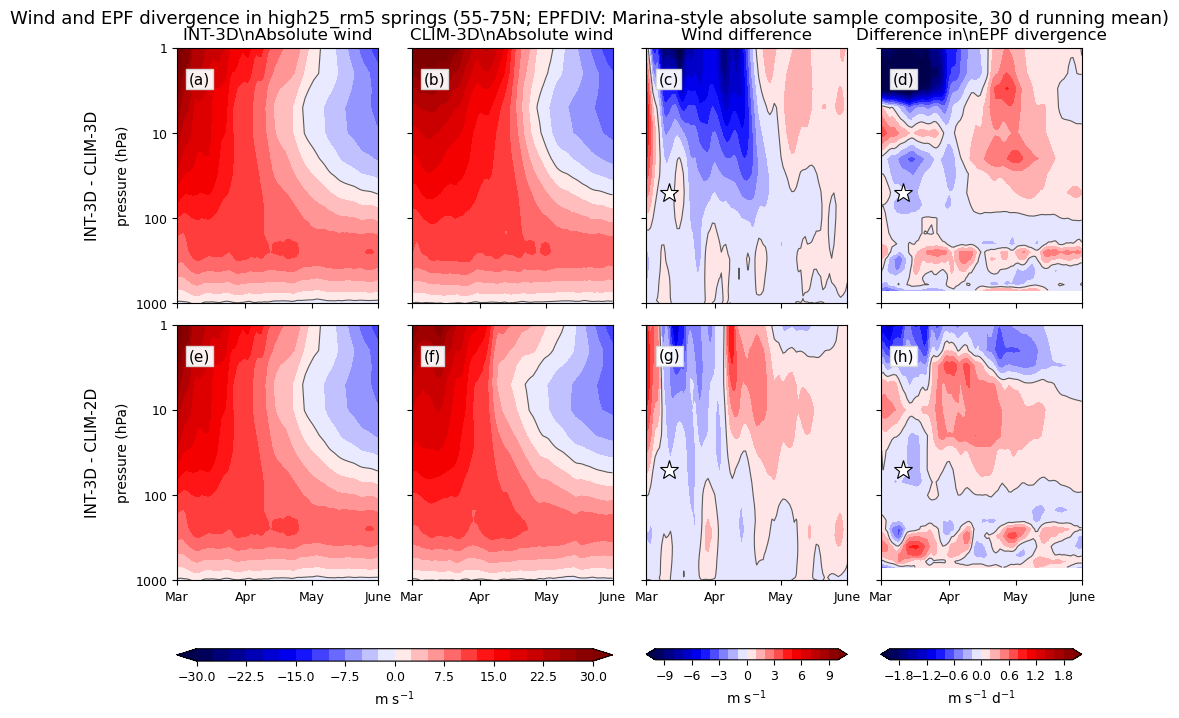

In [21]:
import os
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# ============================================================
# Marina/Friedel Fig.-8-style diagnostic from timefixed climatologies
# ============================================================
# Friedel et al. Fig. 8 uses high-ozone springs, absolute wind composites,
# and absolute EP-flux divergence composites with a 30-day running mean.
# Here EPFDIV is div1 + div2 from our aostools EP-flux files.

FIG8_ROOT = "/mnt/soclim0/public_data/weiji"
FIG8_CASES = {
    "INT-3D": os.path.join(FIG8_ROOT, "B2000WCN001002_timefixed", "climatology"),
    "CLIM-3D": os.path.join(FIG8_ROOT, "B2000WCN007009010011_Clim3D_timefixed", "climatology"),
    "CLIM-2D": os.path.join(FIG8_ROOT, "B2000WCN_NOCOUPL001002_timefixed", "climatology"),
}
FIG8_COMPARISONS = [
    ("INT-3D", "CLIM-3D"),
    ("INT-3D", "CLIM-2D"),
]
FIG8_SAMPLE = "high25_rm5"  # Fig. 8-style high-ozone sample after Climatology writes raw/rm5 extremes
FIG8_LAT_BAND = (55.0, 75.0)
FIG8_PLEV_RANGE_HPA = (1.0, 1000.0)
FIG8_DOY_SLICE = slice(59, 151)  # Mar 1 to May 31 in no-leap, matching Marina range(92)
FIG8_XTICKS = [0, 31, 61, 91]
FIG8_XTICK_LABELS = ["Mar", "Apr", "May", "June"]
FIG8_PLEV_TICKS = [1000, 100, 10, 1]
FIG8_ROLLING_DAYS_EPFDIV = 30
FIG8_EPFDIV_COMPONENTS = ("div1_all_waves", "div2_all_waves")  # total EPF divergence
FIG8_EPFDIV_USE_SAMPLE_MINUS_ALL = False  # Marina uses absolute EPFDIV composites, not sample-minus-all anomalies
FIG8_EPFDIV_SCALE = 1.0  # our div1/div2 files are already in m s^-1 d^-1
FIG8_SAVE = False
FIG8_OUT = "/home/weiji/restart_exam/code_cleaned/Longrun/date_treatment/plots"
FIG8_O3_PRESSURE_TAG = "30_70hPa"
FIG8_O3_VALID_MIN_DU = 10.0
FIG8_O3_STAR_WINDOW_DOY = (60, 120)  # Mar 1-Apr 30, same MA ozone-ranking window
FIG8_DRAW_O3_STAR = True
FIG8_STAR_PRESSURE_HPA = 50.0
FIG8_O3_RANKING_CSVS = {
    "INT-3D": os.path.join(FIG8_ROOT, "B2000WCN001002_timefixed", "partial_O3", "B2000WCN_partial_O3_ranking_MarApr_min_60_90N.csv"),
    "CLIM-3D": os.path.join(FIG8_ROOT, "B2000WCN007009010011_Clim3D_timefixed", "partial_O3", "B2000WCN007009010011_Clim3D_partial_O3_ranking_MarApr_min_60_90N.csv"),
    "CLIM-2D": os.path.join(FIG8_ROOT, "B2000WCN_NOCOUPL001002_timefixed", "partial_O3", "B2000WCN_NOCOUPL_partial_O3_ranking_MarApr_min_60_90N.csv"),
}
FIG8_O3_PARTIAL_NCS = {
    "INT-3D": os.path.join(FIG8_ROOT, "B2000WCN001002_timefixed", "partial_O3", "B2000WCN_partial_O3_all_ranges.nc"),
    "CLIM-3D": os.path.join(FIG8_ROOT, "B2000WCN007009010011_Clim3D_timefixed", "partial_O3", "B2000WCN007009010011_Clim3D_partial_O3_all_ranges.nc"),
    "CLIM-2D": os.path.join(FIG8_ROOT, "B2000WCN_NOCOUPL001002_timefixed", "partial_O3", "B2000WCN_NOCOUPL_partial_O3_all_ranges.nc"),
}

FIG8_U_ABS_LEVELS = np.linspace(-30.0, 30.0, 25)
FIG8_U_DIFF_LEVELS = np.linspace(-10.0, 10.0, 21)
FIG8_EPFDIV_LEVELS = np.linspace(-2.0, 2.0, 21)

mpl.rc("xtick", direction="out", labelsize=9)
mpl.rc("ytick", direction="out", labelsize=9)
mpl.rc("axes", titlesize=11, labelsize=10)
mpl.rc("font", family="sans-serif")


def fig8_normalize_plev_to_hpa(da):
    p = np.asarray(da["plev"].values, dtype=float)
    p_hpa = p / 100.0 if np.nanmax(np.abs(p)) > 1000.0 else p
    return da.assign_coords(plev=p_hpa)


def fig8_select_lat_band(da, lat_band=FIG8_LAT_BAND):
    lat_min, lat_max = lat_band
    lat_vals = np.asarray(da["lat"].values, dtype=float)
    if lat_vals[0] <= lat_vals[-1]:
        return da.sel(lat=slice(lat_min, lat_max))
    return da.sel(lat=slice(lat_max, lat_min))


def fig8_lat_weighted_mean(da, lat_band=FIG8_LAT_BAND):
    da = fig8_select_lat_band(da, lat_band=lat_band)
    weights = np.cos(np.deg2rad(da["lat"]))
    return da.weighted(weights).mean("lat")


def fig8_common_reduce(da):
    da = fig8_normalize_plev_to_hpa(da)
    lo, hi = FIG8_PLEV_RANGE_HPA
    da = da.where((da["plev"] >= lo) & (da["plev"] <= hi), drop=True)
    da = da.isel(doy=FIG8_DOY_SLICE)
    da = da.assign_coords(plot_day=("doy", np.arange(da.sizes["doy"], dtype=int)))
    out = da.swap_dims({"doy": "plot_day"})
    if "doy" in out.coords:
        out = out.drop_vars("doy")
    return out.transpose("plev", "plot_day")


def fig8_var_name(ds, stem, sample):
    name = f"{stem}_clim_{sample}"
    if name not in ds.data_vars:
        available = sorted(v for v in ds.data_vars if v.startswith(f"{stem}_clim_"))
        raise KeyError(f"{name} not found. Available for {stem}: {available}")
    return name


def fig8_load_u(case_label, sample):
    path = os.path.join(FIG8_CASES[case_label], "U_climatology_plev_doy.nc")
    with xr.open_dataset(path, decode_times=False) as ds:
        name = fig8_var_name(ds, "U", sample)
        da = ds[name]
        if "lon" in da.dims:
            da = da.mean("lon", skipna=True)
        da = fig8_lat_weighted_mean(da)
        da = fig8_common_reduce(da).load()
    da.attrs["source_path"] = path
    da.attrs["source_var"] = name
    return da


def fig8_epfdiv_total(ds, sample):
    pieces = []
    missing = []
    for stem in FIG8_EPFDIV_COMPONENTS:
        name = f"{stem}_clim_{sample}"
        if name in ds.data_vars:
            pieces.append(ds[name])
        else:
            missing.append(name)
    if missing:
        available = sorted(v for v in ds.data_vars if "div" in v and v.endswith(f"clim_{sample}"))
        raise KeyError(f"Missing EPFDIV components {missing}. Available div vars for sample={sample}: {available}")
    total = pieces[0]
    for piece in pieces[1:]:
        total = total + piece
    total.name = f"sum({' + '.join(FIG8_EPFDIV_COMPONENTS)})_clim_{sample}"
    return total


def fig8_load_epfdiv(case_label, sample):
    path = os.path.join(FIG8_CASES[case_label], "EPFLUX_climatology_plev_doy.nc")
    with xr.open_dataset(path, decode_times=False) as ds:
        da = fig8_epfdiv_total(ds, sample)
        if FIG8_EPFDIV_USE_SAMPLE_MINUS_ALL and sample != "all":
            da = da - fig8_epfdiv_total(ds, "all")
            da.name = f"EPFDIV_{sample}_minus_all"
        da = da * FIG8_EPFDIV_SCALE
        da = fig8_lat_weighted_mean(da)
        if FIG8_ROLLING_DAYS_EPFDIV and FIG8_ROLLING_DAYS_EPFDIV > 1:
            da = da.rolling(doy=FIG8_ROLLING_DAYS_EPFDIV, center=True, min_periods=max(3, FIG8_ROLLING_DAYS_EPFDIV // 3)).mean()
        da = fig8_common_reduce(da).load()
    da.attrs["source_path"] = path
    da.attrs["source_var"] = da.name or "EPFDIV"
    return da


def fig8_check_sample_availability(sample):
    rows = []
    for case_label, root in FIG8_CASES.items():
        u_path = os.path.join(root, "U_climatology_plev_doy.nc")
        ep_path = os.path.join(root, "EPFLUX_climatology_plev_doy.nc")
        with xr.open_dataset(u_path, decode_times=False) as ds_u:
            u_ok = f"U_clim_{sample}" in ds_u.data_vars
            u_available = sorted(v.replace("U_clim_", "") for v in ds_u.data_vars if v.startswith("U_clim_"))
        with xr.open_dataset(ep_path, decode_times=False) as ds_ep:
            ep_ok = all(f"{stem}_clim_{sample}" in ds_ep.data_vars for stem in FIG8_EPFDIV_COMPONENTS)
            ep_available = sorted({v.split("_clim_")[-1] for v in ds_ep.data_vars if "div" in v and "_clim_" in v})
        rows.append({
            "case": case_label,
            "U_sample_ok": u_ok,
            "U_available_samples": ",".join(u_available),
            "EPFDIV_sample_ok": ep_ok,
            "EPFDIV_available_samples": ",".join(ep_available),
        })
    return pd.DataFrame(rows)


def fig8_format_axis(ax, show_xlabel=False, show_ylabel=False):
    # Marina plots log(pressure) as the coordinate, with manual pressure labels.
    lo, hi = FIG8_PLEV_RANGE_HPA
    ax.set_ylim(np.log(hi), np.log(lo))
    ticks = np.asarray(FIG8_PLEV_TICKS, dtype=float)
    ax.set_yticks(np.log(ticks))
    ax.set_yticklabels([f"{int(t):d}" for t in ticks])
    ax.set_xlim(0, FIG8_DOY_SLICE.stop - FIG8_DOY_SLICE.start - 1)
    ax.set_xticks(FIG8_XTICKS)
    ax.set_xticklabels(FIG8_XTICK_LABELS)
    ax.grid(False)
    if show_ylabel:
        ax.set_ylabel("pressure (hPa)")
    if show_xlabel:
        ax.set_xlabel("")


def fig8_panel(ax, da, levels, cmap, title=None, zero=True, label=None):
    x = da["plot_day"].values
    p = da["plev"].values.astype(float)
    y = np.log(p)
    z = da.values.astype(float)
    cf = ax.contourf(x, y, z, levels=levels, cmap=plt.cm.get_cmap(cmap), extend="both")
    if zero:
        try:
            ax.contour(x, y, z, levels=[0.0], colors="0.35", linewidths=0.8)
        except Exception:
            pass
    if title:
        ax.set_title(title, fontsize=12)
    if label:
        ax.text(
            0.06, 0.86, label,
            transform=ax.transAxes, fontsize=11,
            bbox=dict(facecolor="white", edgecolor="0.85", alpha=0.95, pad=2.0),
        )
    return cf


def fig8_date_to_doy_no_leap(date_values):
    date_values = np.asarray(date_values, dtype=np.int64)
    mmdd = date_values % 10000
    month = (mmdd // 100).astype(np.int16)
    day = (mmdd % 100).astype(np.int16)
    month_ends = np.array([31, 59, 90, 120, 151, 181, 212, 243, 273, 304, 334, 365])
    doy = np.full(date_values.shape, -9999, dtype=np.int16)
    for m in range(1, 13):
        mask = month == m
        if np.any(mask):
            prev = int(month_ends[m - 2]) if m > 1 else 0
            doy[mask] = prev + day[mask]
    return doy.astype(int)


def fig8_calendar_from_time(time_values):
    day_index = np.asarray(time_values, dtype=float).astype(np.int64)
    year = day_index // 365 + 1
    doy = day_index % 365 + 1
    return year.astype(int), doy.astype(int)


def fig8_partial_o3_calendar(ds):
    if "date" in ds:
        dates = ds["date"].values.astype(np.int64)
        return (dates // 10000).astype(int), fig8_date_to_doy_no_leap(dates)
    return fig8_calendar_from_time(ds["time"].values)


def fig8_o3_partial_var(ds):
    direct = f"O3_partial_60_90N_{FIG8_O3_PRESSURE_TAG}"
    if direct in ds.data_vars:
        return ds[direct]
    if "O3_partial_60_90N" in ds.data_vars:
        return ds["O3_partial_60_90N"].sel(pressure_range=FIG8_O3_PRESSURE_TAG)
    candidates = [v for v in ds.data_vars if v.startswith("O3_partial_60_90N")]
    raise KeyError(f"Cannot find partial O3 variable for {FIG8_O3_PRESSURE_TAG}. Candidates: {candidates}")


def fig8_o3_extreme_years(case_label, sample):
    method = "rm5" if sample.endswith("_rm5") else "raw"
    if sample.startswith("high"):
        flag = f"is_highest25pct_{method}"
    elif sample.startswith("low"):
        flag = f"is_lowest25pct_{method}"
    else:
        return []

    csv_path = FIG8_O3_RANKING_CSVS.get(case_label)
    if not csv_path or not os.path.exists(csv_path):
        print(f"[FIG8] no O3 ranking CSV for star: {case_label}: {csv_path}")
        return []
    df = pd.read_csv(csv_path)
    if "pressure_range" in df.columns:
        df = df[df["pressure_range"].astype(str) == FIG8_O3_PRESSURE_TAG]
    if flag not in df.columns:
        print(f"[FIG8] ranking CSV lacks {flag}; star skipped for {case_label}")
        return []
    return sorted(df.loc[df[flag].astype(bool), "year"].astype(int).unique().tolist())


def fig8_o3_extreme_star_day(case_label, sample):
    if not FIG8_DRAW_O3_STAR:
        return None
    years = fig8_o3_extreme_years(case_label, sample)
    if not years:
        return None
    nc_path = FIG8_O3_PARTIAL_NCS.get(case_label)
    if not nc_path or not os.path.exists(nc_path):
        print(f"[FIG8] no partial O3 nc for star: {case_label}: {nc_path}")
        return None

    method = "rm5" if sample.endswith("_rm5") else "raw"
    want_high = sample.startswith("high")
    start_doy, end_doy = FIG8_O3_STAR_WINDOW_DOY

    with xr.open_dataset(nc_path, decode_times=False) as ds:
        da = fig8_o3_partial_var(ds).load()
        year_arr, doy_arr = fig8_partial_o3_calendar(ds)

    vals = np.asarray(da.values, dtype=float)
    vals = np.where(vals > FIG8_O3_VALID_MIN_DU, vals, np.nan)
    if method == "rm5":
        vals = pd.Series(vals).rolling(window=5, center=True, min_periods=5).mean().to_numpy()

    event_days = []
    for y in years:
        mask = (year_arr == y) & (doy_arr >= start_doy) & (doy_arr <= end_doy) & np.isfinite(vals)
        if not np.any(mask):
            continue
        sub_vals = vals[mask]
        sub_doy = doy_arr[mask]
        idx = int(np.nanargmax(sub_vals) if want_high else np.nanargmin(sub_vals))
        event_days.append(float(sub_doy[idx] - start_doy))

    if not event_days:
        return None
    return float(np.nanmean(event_days))


def fig8_draw_star(ax, x_day, p_hpa=FIG8_STAR_PRESSURE_HPA):
    if x_day is None or not np.isfinite(x_day):
        return
    ax.plot(
        x_day, np.log(float(p_hpa)), marker="*", markersize=14,
        color="white", markeredgecolor="black", markeredgewidth=0.8,
        linestyle="None", zorder=8,
    )


def plot_fig8_style_wind_epfdiv(sample=FIG8_SAMPLE):
    availability = fig8_check_sample_availability(sample)
    print("Figure-8-style sample availability:")
    print(availability.to_string(index=False))
    if not availability[["U_sample_ok", "EPFDIV_sample_ok"]].to_numpy().all():
        raise KeyError(
            f"Requested sample={sample!r} is not available for all cases. "
            "Current files must contain all/low25_raw/low25_rm5/high25_raw/high25_rm5 samples."
        )

    nrow = len(FIG8_COMPARISONS)
    ncol = 4
    fig, axes = plt.subplots(
        nrow, ncol, figsize=(2.35 * ncol + 0.8, 3.05 * nrow + 0.8),
        sharex=True, sharey=True, constrained_layout=True,
    )
    if nrow == 1:
        axes = np.asarray([axes])

    cf_abs = cf_wdiff = cf_ep = None
    letters = iter("abcdefghijklmnopqrstuvwxyz")
    stats_rows = []

    for i, (case_a, case_b) in enumerate(FIG8_COMPARISONS):
        u_a = fig8_load_u(case_a, sample)
        u_b = fig8_load_u(case_b, sample)
        u_a, u_b = xr.align(u_a, u_b, join="inner")
        u_diff = (u_a - u_b).load()

        ep_a = fig8_load_epfdiv(case_a, sample)
        ep_b = fig8_load_epfdiv(case_b, sample)
        ep_a, ep_b = xr.align(ep_a, ep_b, join="inner")
        ep_diff = (ep_a - ep_b).load()

        row_label = f"{case_a} - {case_b}"
        star_day = fig8_o3_extreme_star_day(case_a, sample)
        panels = [
            (u_a, FIG8_U_ABS_LEVELS, "seismic", f"{case_a}\\nAbsolute wind", True, "m s$^{-1}$"),
            (u_b, FIG8_U_ABS_LEVELS, "seismic", f"{case_b}\\nAbsolute wind", True, "m s$^{-1}$"),
            (u_diff, FIG8_U_DIFF_LEVELS, "seismic", "Wind difference", True, "m s$^{-1}$"),
            (ep_diff, FIG8_EPFDIV_LEVELS, "seismic", "Difference in\\nEPF divergence", True, "m s$^{-1}$ d$^{-1}$"),
        ]

        for j, (da, levels, cmap, title, zero, units) in enumerate(panels):
            ax = axes[i, j]
            cf = fig8_panel(ax, da, levels=levels, cmap=cmap, title=title if i == 0 else None, zero=zero, label=f"({next(letters)})")
            fig8_format_axis(ax, show_xlabel=(i == nrow - 1), show_ylabel=(j == 0))
            if j == 0:
                ax.text(-0.42, 0.5, row_label, rotation=90, transform=ax.transAxes, ha="center", va="center", fontsize=11)
            if j >= 2:
                fig8_draw_star(ax, star_day)
            if j in [0, 1]:
                cf_abs = cf
            elif j == 2:
                cf_wdiff = cf
            else:
                cf_ep = cf

        stats_rows.append({
            "comparison": row_label,
            "sample": sample,
            "lat_band": f"{FIG8_LAT_BAND[0]:g}-{FIG8_LAT_BAND[1]:g}N",
            "o3_star_day_from_mar1": np.nan if star_day is None else star_day,
            "u_diff_mean": float(np.nanmean(u_diff.values)),
            "u_diff_mae": float(np.nanmean(np.abs(u_diff.values))),
            "u_diff_max_abs": float(np.nanmax(np.abs(u_diff.values))),
            "epfdiv_diff_mean": float(np.nanmean(ep_diff.values)),
            "epfdiv_diff_mae": float(np.nanmean(np.abs(ep_diff.values))),
            "epfdiv_diff_max_abs": float(np.nanmax(np.abs(ep_diff.values))),
        })

    cbar_abs = fig.colorbar(cf_abs, ax=axes[:, 0:2], orientation="horizontal", pad=0.08, fraction=0.06, aspect=35)
    cbar_abs.set_label("m s$^{-1}$")
    cbar_diff = fig.colorbar(cf_wdiff, ax=axes[:, 2], orientation="horizontal", pad=0.08, fraction=0.06, aspect=18)
    cbar_diff.set_label("m s$^{-1}$")
    cbar_ep = fig.colorbar(cf_ep, ax=axes[:, 3], orientation="horizontal", pad=0.08, fraction=0.06, aspect=18)
    cbar_ep.set_label("m s$^{-1}$ d$^{-1}$")

    ep_note = "sample-minus-all anomalies" if FIG8_EPFDIV_USE_SAMPLE_MINUS_ALL and sample != "all" else "Marina-style absolute sample composite"
    fig.suptitle(
        f"Wind and EPF divergence in {sample} springs ({FIG8_LAT_BAND[0]:.0f}-{FIG8_LAT_BAND[1]:.0f}N; EPFDIV: {ep_note}, {FIG8_ROLLING_DAYS_EPFDIV} d running mean)",
        fontsize=13,
        y=1.02,
    )

    stats = pd.DataFrame(stats_rows)
    print()
    print("Figure-8-style diagnostics:")
    print(stats.to_string(index=False, float_format=lambda x: f"{x:.6g}"))

    if FIG8_SAVE:
        os.makedirs(FIG8_OUT, exist_ok=True)
        out_png = os.path.join(FIG8_OUT, f"figure8_style_wind_epfdiv_{sample}.png")
        fig.savefig(out_png, dpi=300, bbox_inches="tight")
        print(f"Saved: {out_png}")
    plt.show()
    return stats


fig8_style_stats = plot_fig8_style_wind_epfdiv(FIG8_SAMPLE)
